In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affiche toutes les lignes
pd.set_option('display.max_rows', None)

# Affiche toutes les colonnes 
pd.set_option('display.max_columns', None)
# Choisis le nombre de caractère par colonnes
pd.set_option('display.max_colwidth', 50)

In [178]:
def first_overview(data, name=""):
    print(f'Shape of {name} dataset : {data.shape}\n')
    print(f'Number of duplicate : {data.duplicated().sum()}\n')
    if data.shape[1] < 20:
        print(f'Variable types : \n{data.dtypes}\n')
    else:
        print(f'Variable types : \n{data.dtypes.value_counts()}\n')
    display(data.head())
    display(data.describe().T)
    try:
        display(data.describe(include=('object', 'str')).T)
    except:
        pass
    return 

In [179]:
import matplotlib.ticker as ticker

def plot_duration(data, cols, time):    
    # --- CALCUL DYNAMIQUE DE LA GRILLE ---
    n_cols = 3  # Nombre fixe de colonnes
    n_graphs = len(cols)
    # Calculer le nombre de lignes nécessaire (arrondi à l'entier supérieur)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    
    # Gérer le cas où il n'y a qu'un seul graphique (axes n'est pas un tableau)
    if n_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        ax.plot(data[time], data[col])
        
        ax.set_title(f'{col} curve')
        ax.set_xlabel('Times')
        ax.set_ylabel('Values')
        
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Masquer les sous-graphiques vides s'il y en a (cas où le nombre de graphs n'est pas un multiple de 3)
    for j in range(n_graphs, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def plot_distribution(data, cols):
    # --- CALCUL DYNAMIQUE DE LA GRILLE ---
    n_cols = 3  # Nombre fixe de colonnes
    n_graphs = len(cols)
    # Calculer le nombre de lignes nécessaire (arrondi à l'entier supérieur)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

    # Gérer le cas où il n'y a qu'un seul graphique (axes n'est pas un tableau)
    if n_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.histplot(data=data, x=col, ax=ax)

        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('Values')
        ax.set_ylabel(col)

    # Masquer les sous-graphiques vides s'il y en a (cas où le nombre de graphs n'est pas un multiple de 3)
    for j in range(n_graphs, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def plot_duration_10_min(data, cols, time):
    df_filtered = data[data['Time'] < '00:10:00'].copy()
    
    # --- CALCUL DYNAMIQUE DE LA GRILLE ---
    n_cols = 3  # Nombre fixe de colonnes
    n_graphs = len(cols)
    # Calculer le nombre de lignes nécessaire (arrondi à l'entier supérieur)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    
    # Gérer le cas où il n'y a qu'un seul graphique (axes n'est pas un tableau)
    if n_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        # Tracer la courbe principale
        ax.plot(df_filtered[time], df_filtered[col])
        
        ax.set_title(f'{col} curve on the first 10 minutes')
        ax.set_xlabel('Times')
        ax.set_ylabel('Values')
        
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Masquer les sous-graphiques vides s'il y en a (cas où le nombre de graphs n'est pas un multiple de 3)
    for j in range(n_graphs, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def plot_distribution_by_target(data, cols, target):
    # --- CALCUL DYNAMIQUE DE LA GRILLE ---
    n_cols = 3  # Nombre fixe de colonnes
    n_graphs = len(cols)
    # Calculer le nombre de lignes nécessaire (arrondi à l'entier supérieur)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

    # Gérer le cas où il n'y a qu'un seul graphique (axes n'est pas un tableau)
    if n_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.boxplot(data=data, x=target, y=col, ax=ax)
        ax.set_title(f'Distribution of {col} depending on {target}')
        ax.set_xlabel(target)
        ax.set_ylabel(col)

    # Masquer les sous-graphiques vides s'il y en a (cas où le nombre de graphs n'est pas un multiple de 3)
    for j in range(n_graphs, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()  
    plt.show()

# Import data

In [180]:
data_path = "2.csv"

data_raw = pd.read_csv(data_path)

In [181]:
# Rename sensor
n_cols = len(data_raw.columns)

sensor_name = [data_raw.columns[0]]
sensor_name += [f"R{i}" for i in range(1, n_cols - 1)]
sensor_name.append(data_raw.columns[-1])
data_raw.columns = sensor_name

In [182]:
dict_gaz = {
    'Air': 'A',   
    '1_Bigaradier+': 'B1',  
    '2_Bigaradier++': 'B2', 
    '3_Bigaradier+++': 'B3',
    '4_Geranium+': 'G1',    
    '5_Geranium++': 'G2',      
    '6_Lavande+': 'L1',     
    '7_Lavande++': 'L2',
    '8_Menthe+': 'M1',      
    '9_Menthe++': 'M2',
}

data_raw['gaz'] = data_raw['gaz'].map(dict_gaz)

gases = data_raw['gaz'].unique()
gases

<StringArray>
['A', 'B1', nan, 'G1', 'G2', 'L1', 'L2', 'M1', 'M2']
Length: 9, dtype: str

In [183]:
df = data_raw.copy()

# First overview

In [184]:
first_overview(df)

Shape of  dataset : (3492, 17)

Number of duplicate : 0

Variable types : 
Time      str
R1      int64
R2      int64
R3      int64
R4      int64
R5      int64
R6      int64
R7      int64
R8      int64
R9      int64
R10     int64
R11     int64
R12     int64
R13     int64
R14     int64
R15     int64
gaz       str
dtype: object



,Time,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,R15,gaz
0,00:00:03.222,571294,965505,2425036,340551,2425036,1902493,321701,1902493,3373172,2425036,1120912,3373172,1035133,610784,395526,A
1,00:00:05.024,590348,1035133,5292575,315853,5292575,1902493,321701,2425036,3373172,1902493,1230579,3373172,1120912,590348,404500,A
2,00:00:06.826,536753,965505,3373172,327759,3373172,3373172,315853,5292575,2425036,3373172,1230579,3373172,1035133,656549,404500,A
3,00:00:08.627,553471,1035133,5292575,321701,1902493,1902493,310203,5292575,2425036,2425036,1377459,9704552,1035133,590348,404759,A
4,00:00:10.516,536753,907302,5292575,321701,3373172,1902493,315853,3373172,2425036,1902493,1377459,2425036,1120912,590348,414005,A


,count,mean,std,min,25%,50%,75%,max
R1,3492.0,1.181417e+05,1.565870e+05,10470.0,19803.0,27977.0,168681.00,610784.0
R2,3492.0,2.413454e+05,3.144188e+05,24801.0,43710.0,61086.0,385369.00,1377459.0
R3,3492.0,1.043488e+06,2.692231e+06,29678.0,107421.0,167782.5,814138.00,59502880.0
R4,3492.0,7.219390e+04,1.043645e+05,4467.0,7637.0,12979.0,88716.00,369223.0
R5,3492.0,9.031876e+05,2.101587e+06,48135.0,128658.0,228788.5,907302.00,59502880.0
R6,3492.0,6.073365e+05,1.044903e+06,35588.0,97502.0,182297.0,718276.25,21500960.0
R7,3492.0,8.093483e+04,1.040954e+05,10004.0,16204.0,22290.0,111697.00,369223.0
R8,3492.0,7.270659e+05,1.269503e+06,40940.0,156782.0,215406.0,710535.00,21500960.0
R9,3492.0,3.639114e+05,5.895254e+05,26280.0,46744.0,69195.0,443200.00,9704552.0
R10,3492.0,5.738057e+05,9.627977e+05,37376.0,73442.0,104986.0,710535.00,9704552.0


,count,unique,top,freq
Time,3492,3492,00:00:03.222,1
gaz,2944,8,A,1021


In [185]:
df.isna().sum()

Time      0
R1        0
R2        0
R3        0
R4        0
R5        0
R6        0
R7        0
R8        0
R9        0
R10       0
R11       0
R12       0
R13       0
R14       0
R15       0
gaz     548
dtype: int64

In [186]:
df['Time'] = pd.to_timedelta(df['Time'])
    
print(df['Time'].head())

0   0 days 00:00:03.222000
1   0 days 00:00:05.024000
2   0 days 00:00:06.826000
3   0 days 00:00:08.627000
4   0 days 00:00:10.516000
Name: Time, dtype: timedelta64[us]


# Target

In [187]:
target = 'gaz'

df[target].value_counts(normalize=True)

gaz
A     0.346807
B1    0.093750
G1    0.093750
L1    0.093750
G2    0.093410
L2    0.093071
M1    0.093071
M2    0.092391
Name: proportion, dtype: float64

# All data visualisation

In [188]:
col_R = df.columns[1:-2]
col_R

Index(['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11',
       'R12', 'R13', 'R14'],
      dtype='str')

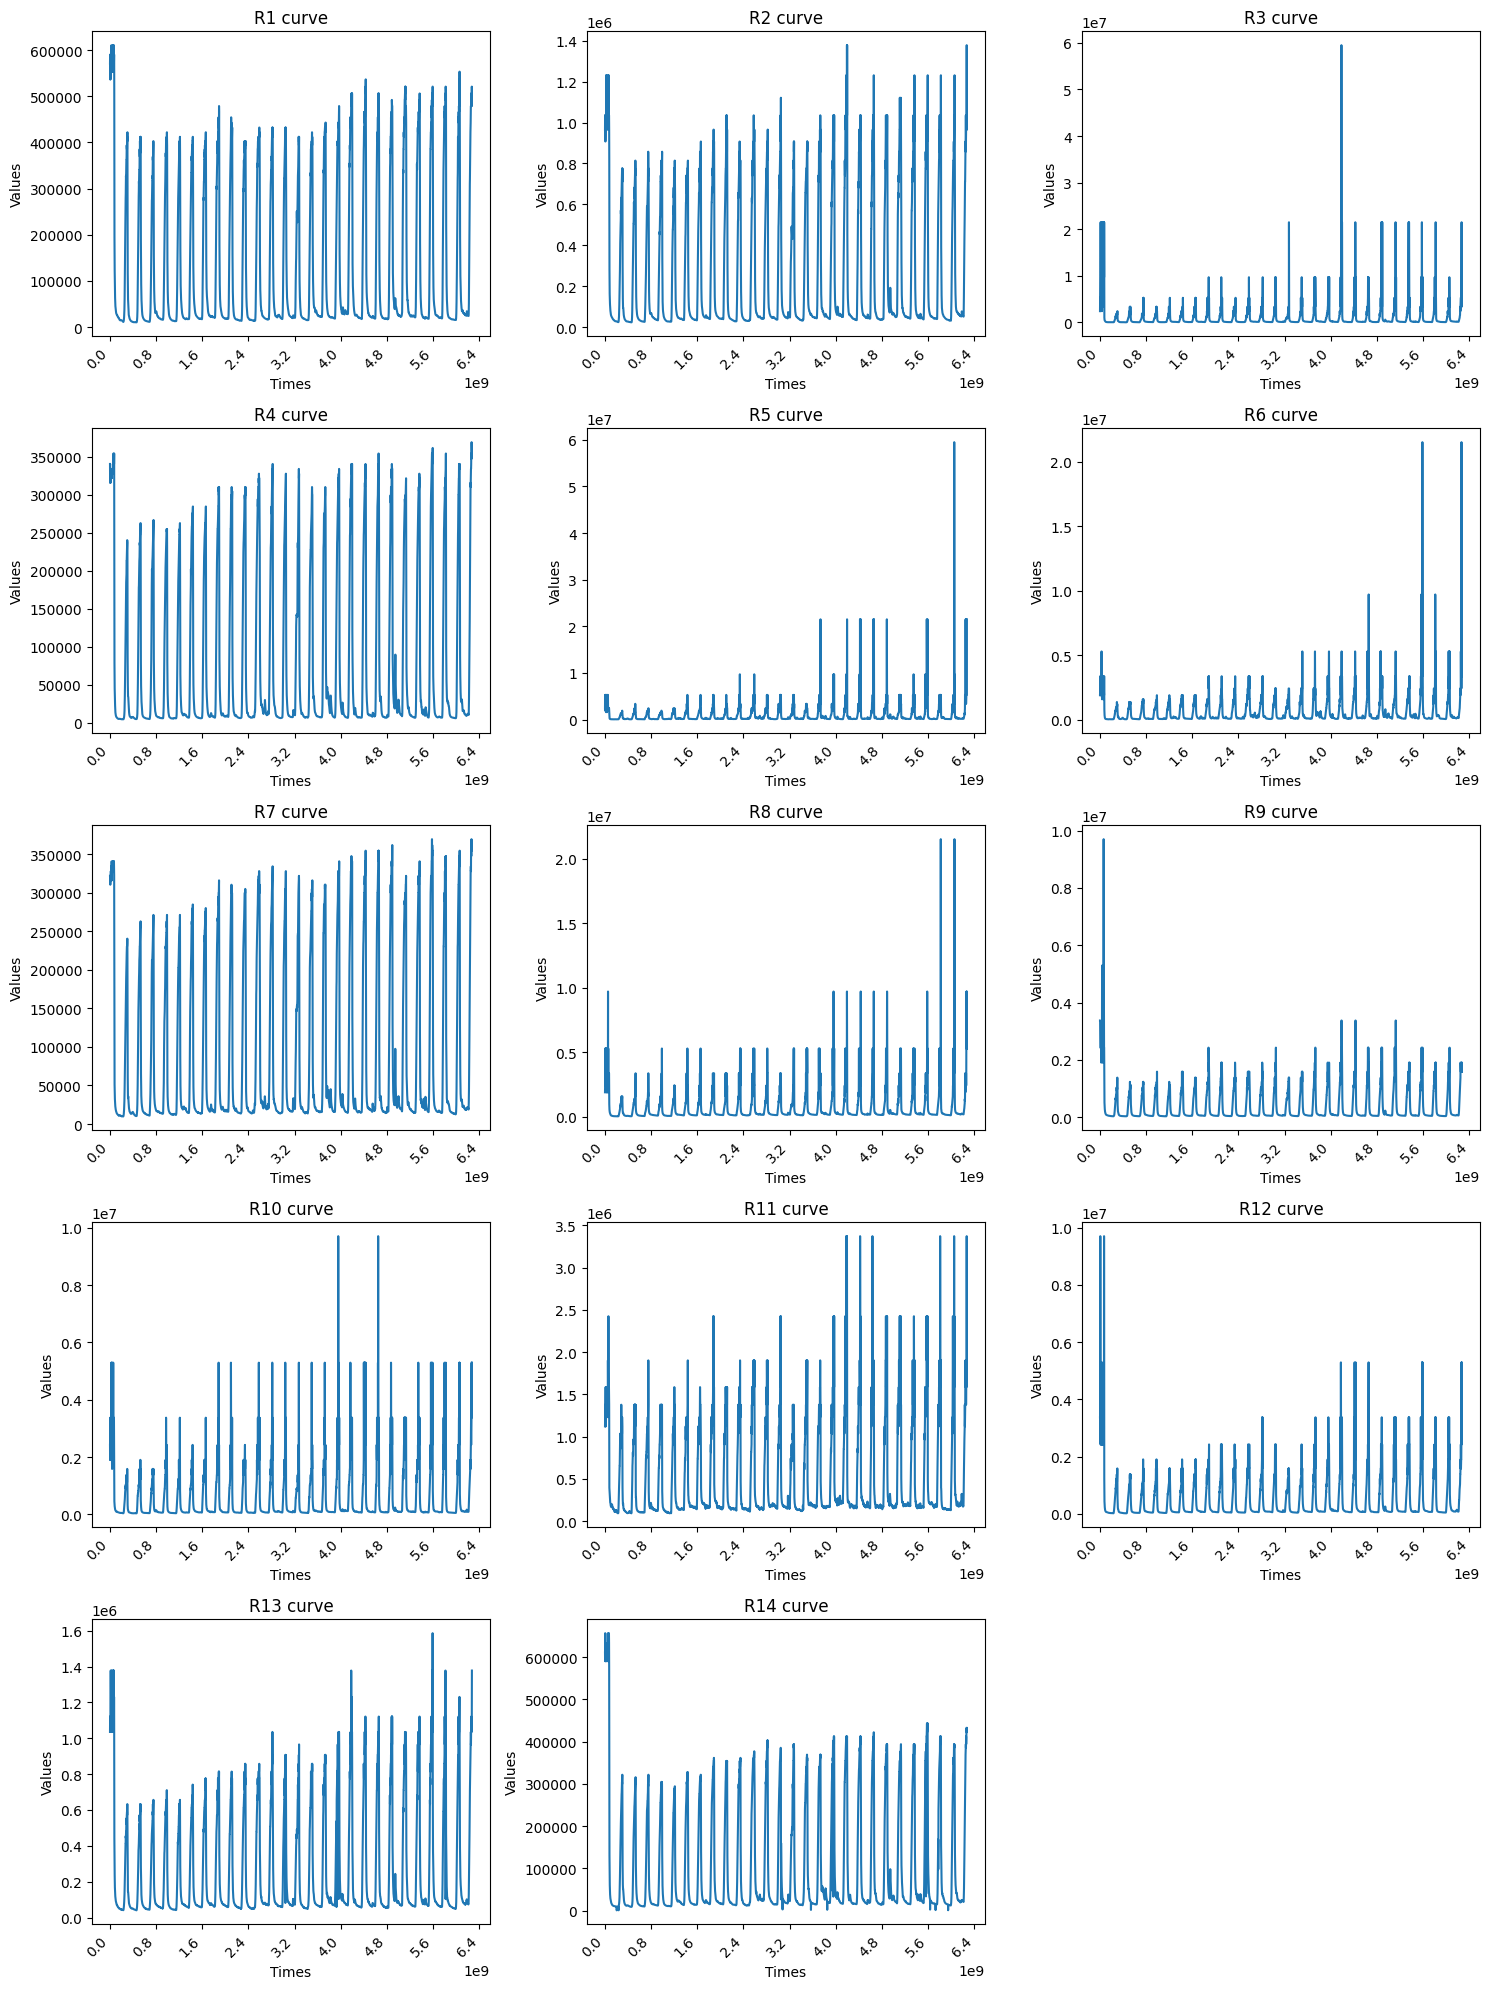

In [189]:
plot_duration(df, col_R, 'Time')

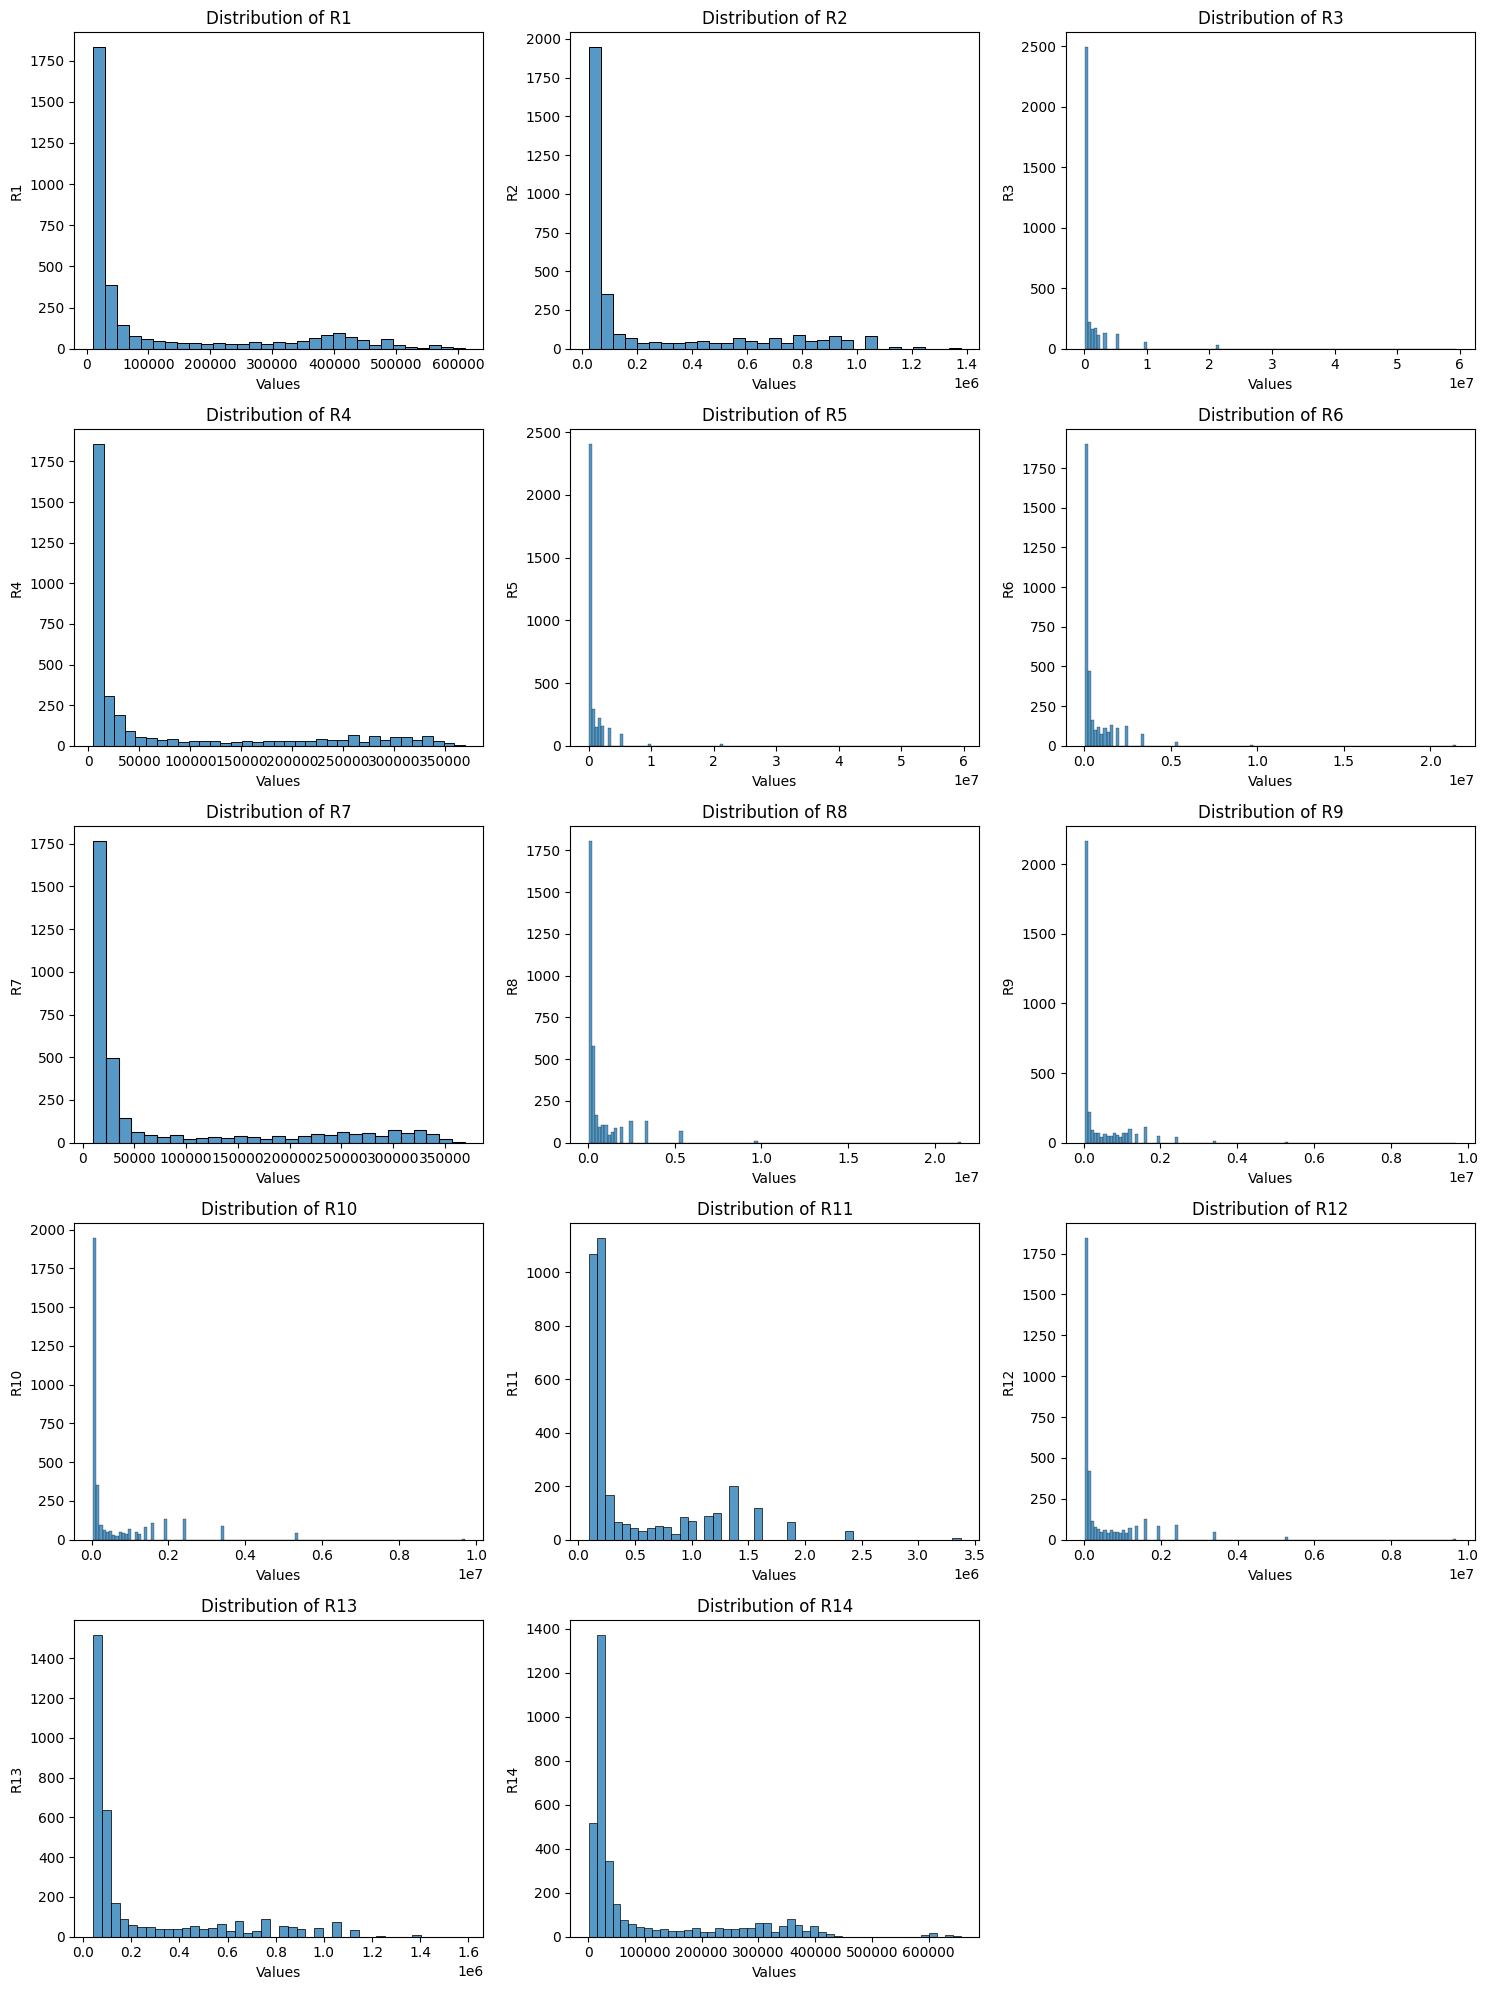

In [190]:
plot_distribution(df, col_R)

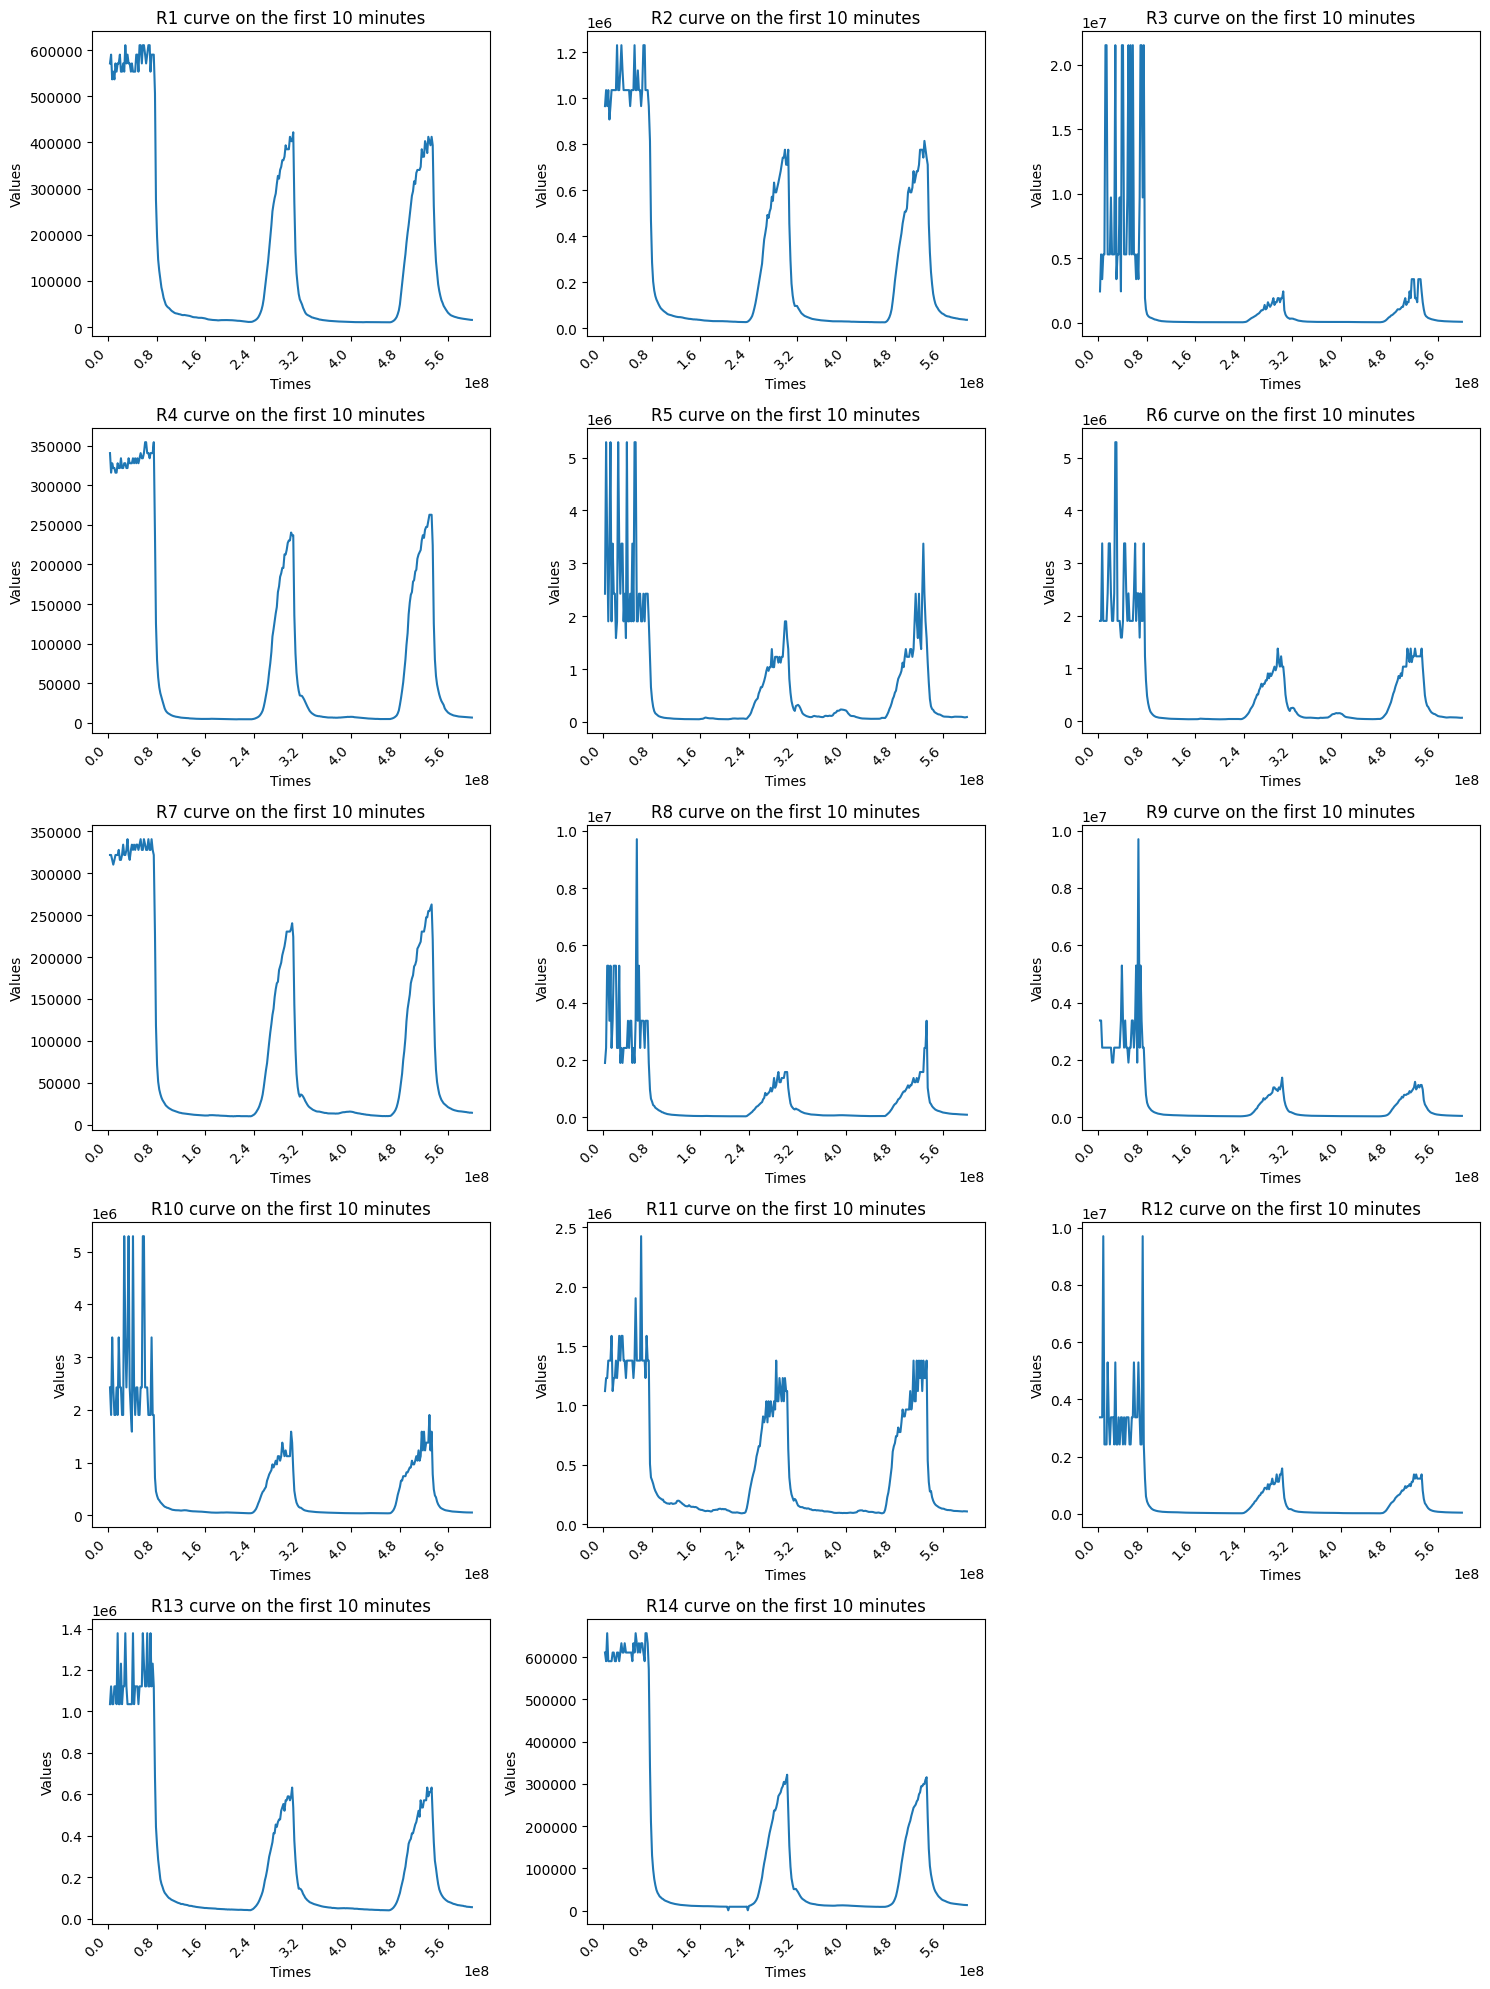

In [191]:
plot_duration_10_min(df, col_R, 'Time')

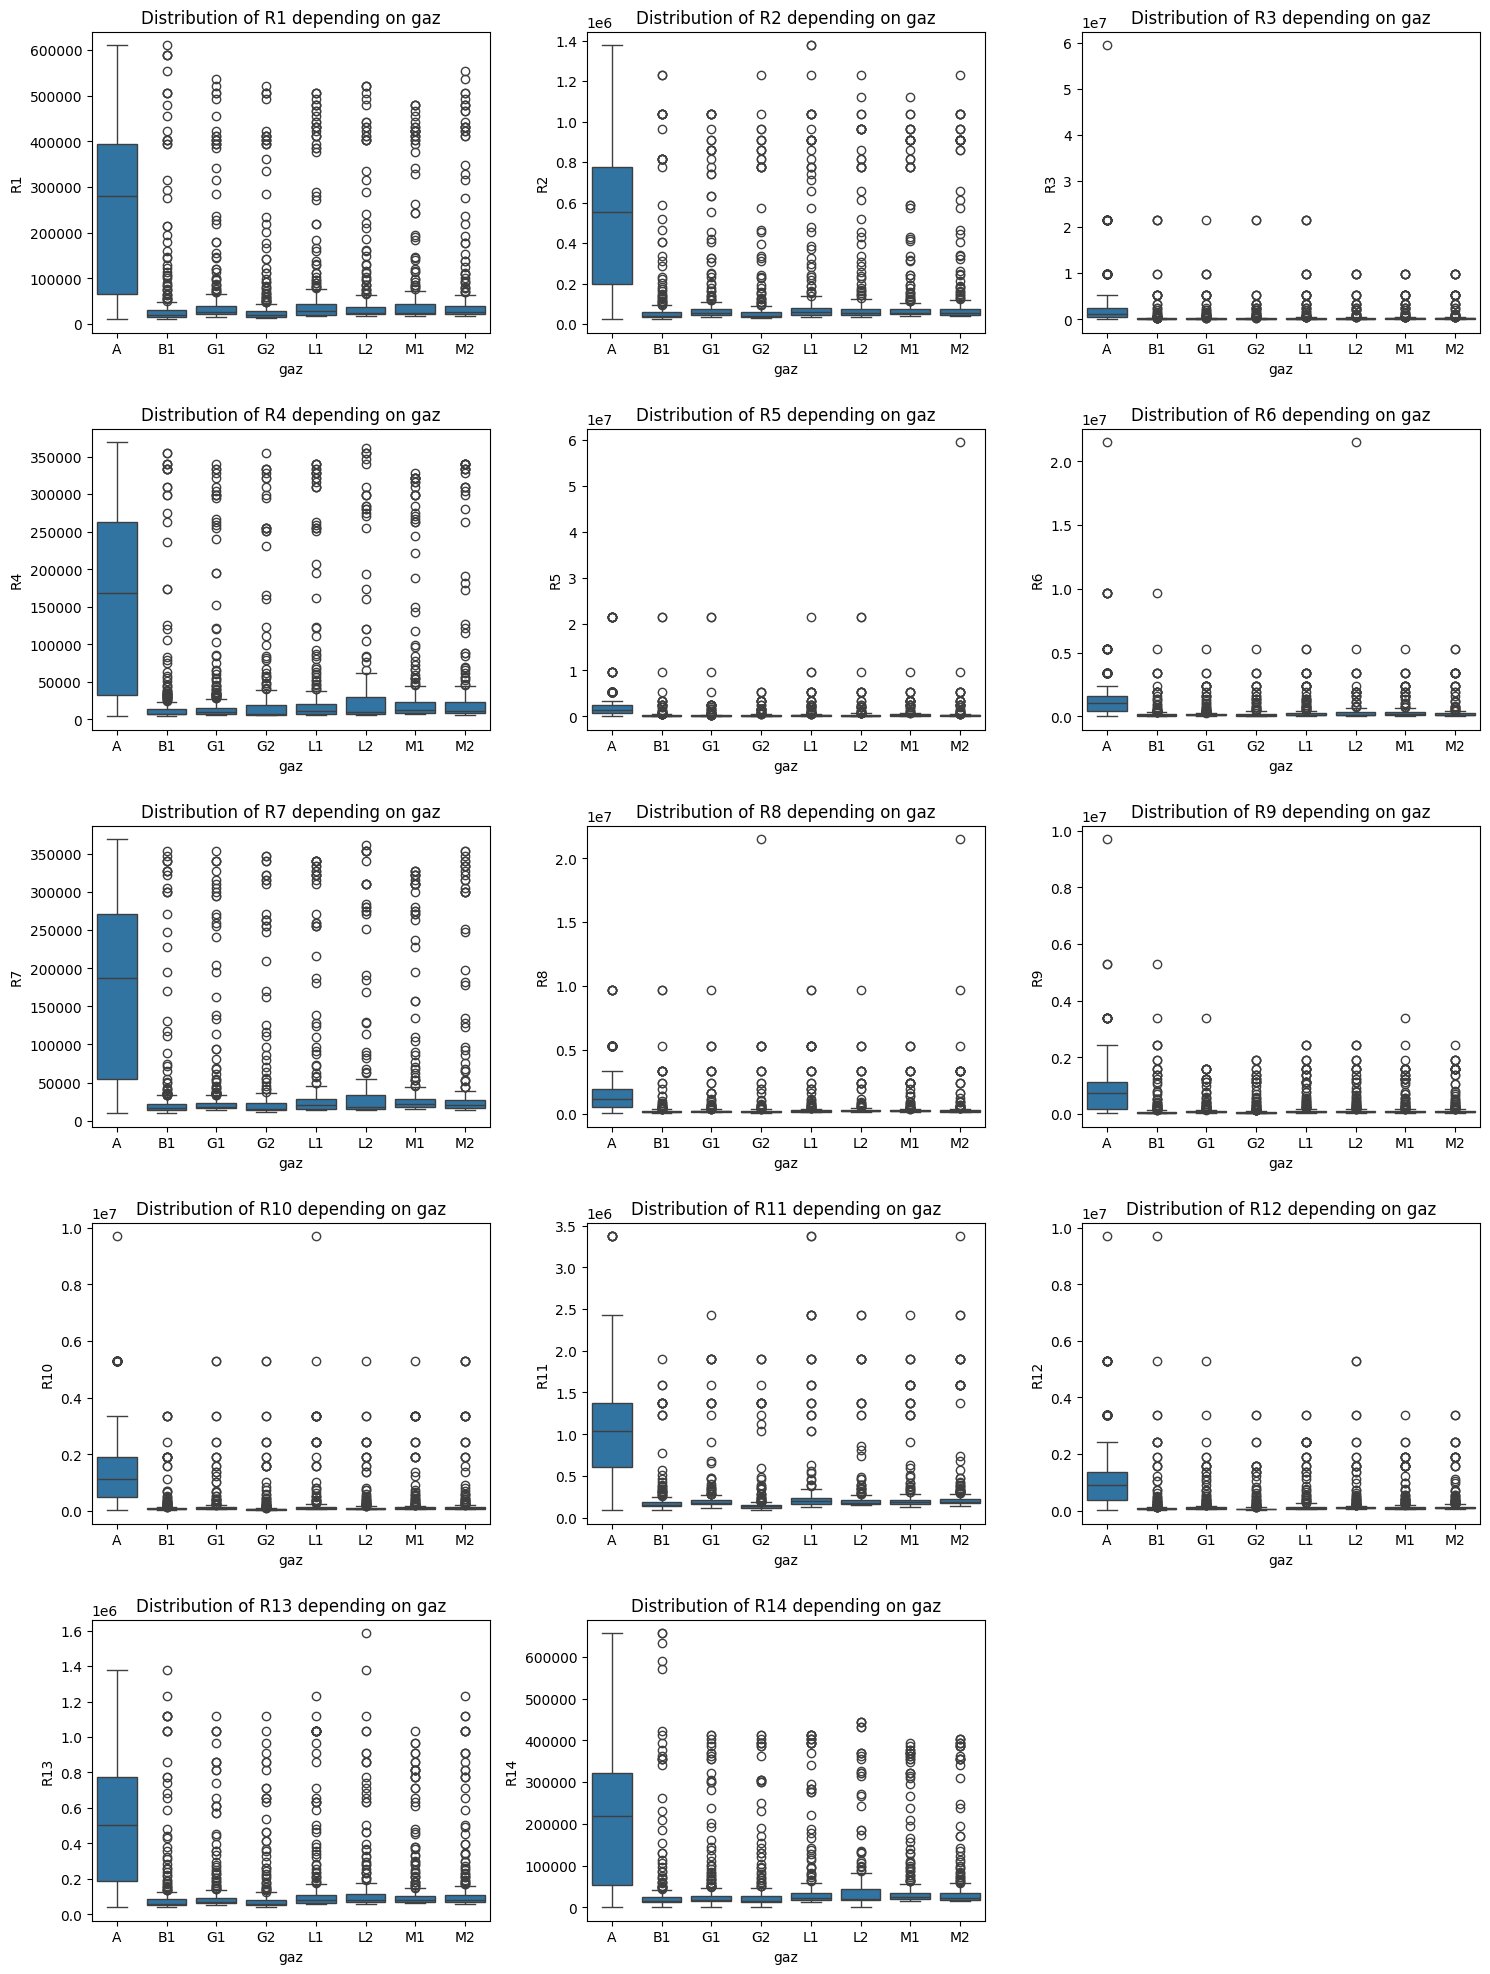

In [192]:
plot_distribution_by_target(df, col_R, target)

# Stable data

In [193]:
df1 = df[df['gaz'] != 'A']

col_R = df.columns[1:-2]
col_R

Index(['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11',
       'R12', 'R13', 'R14'],
      dtype='str')

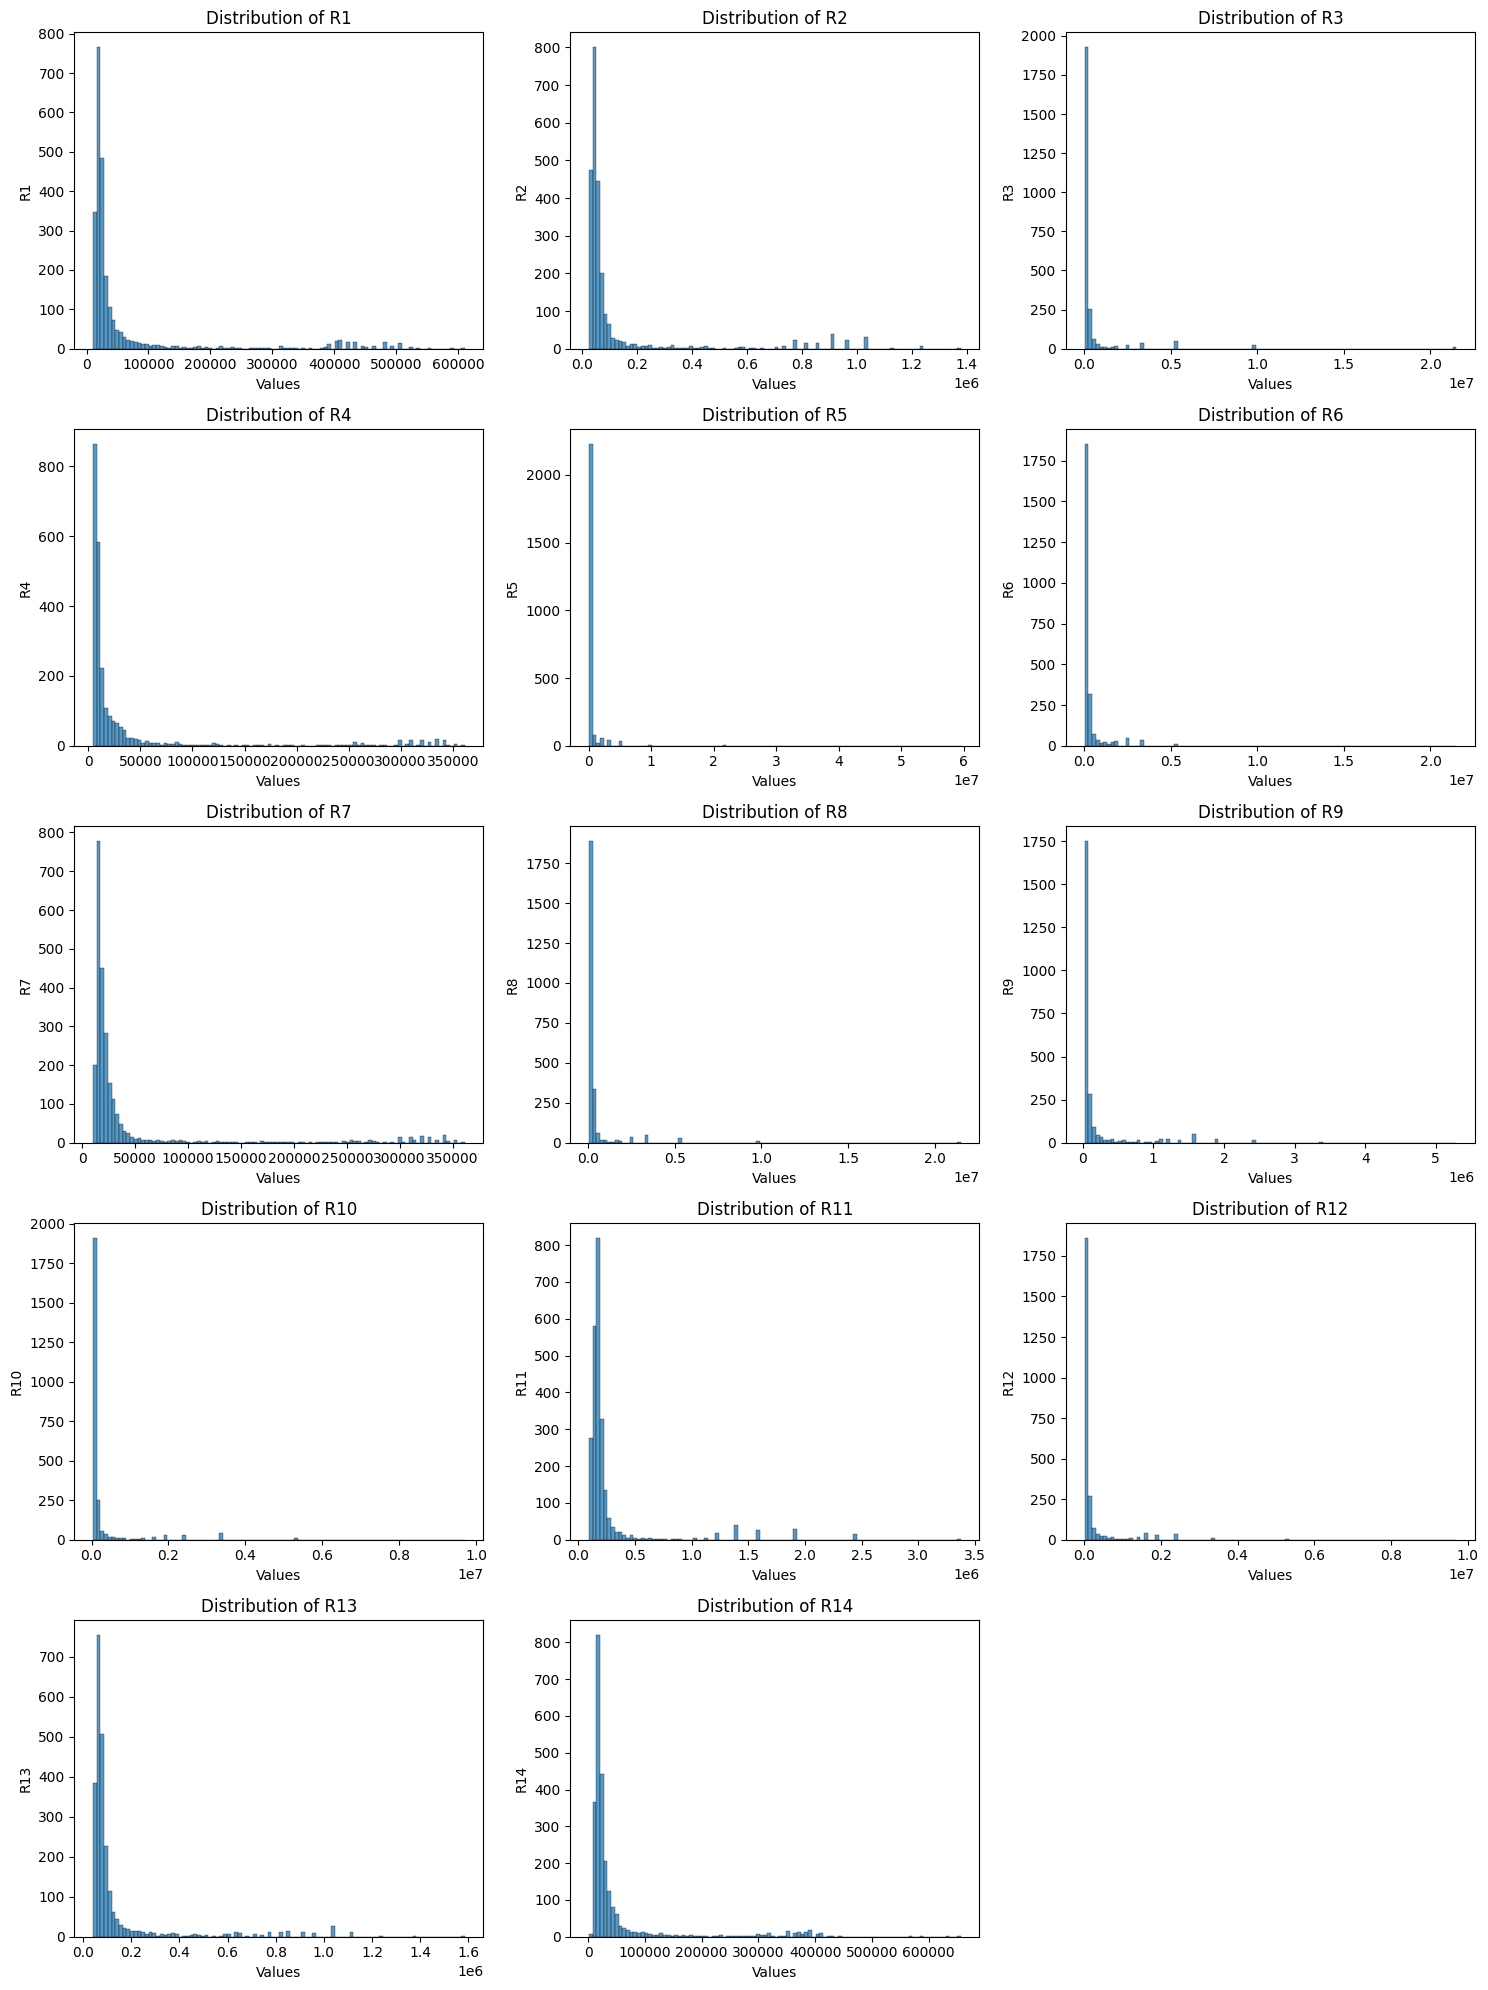

In [194]:
plot_distribution(df1, col_R)

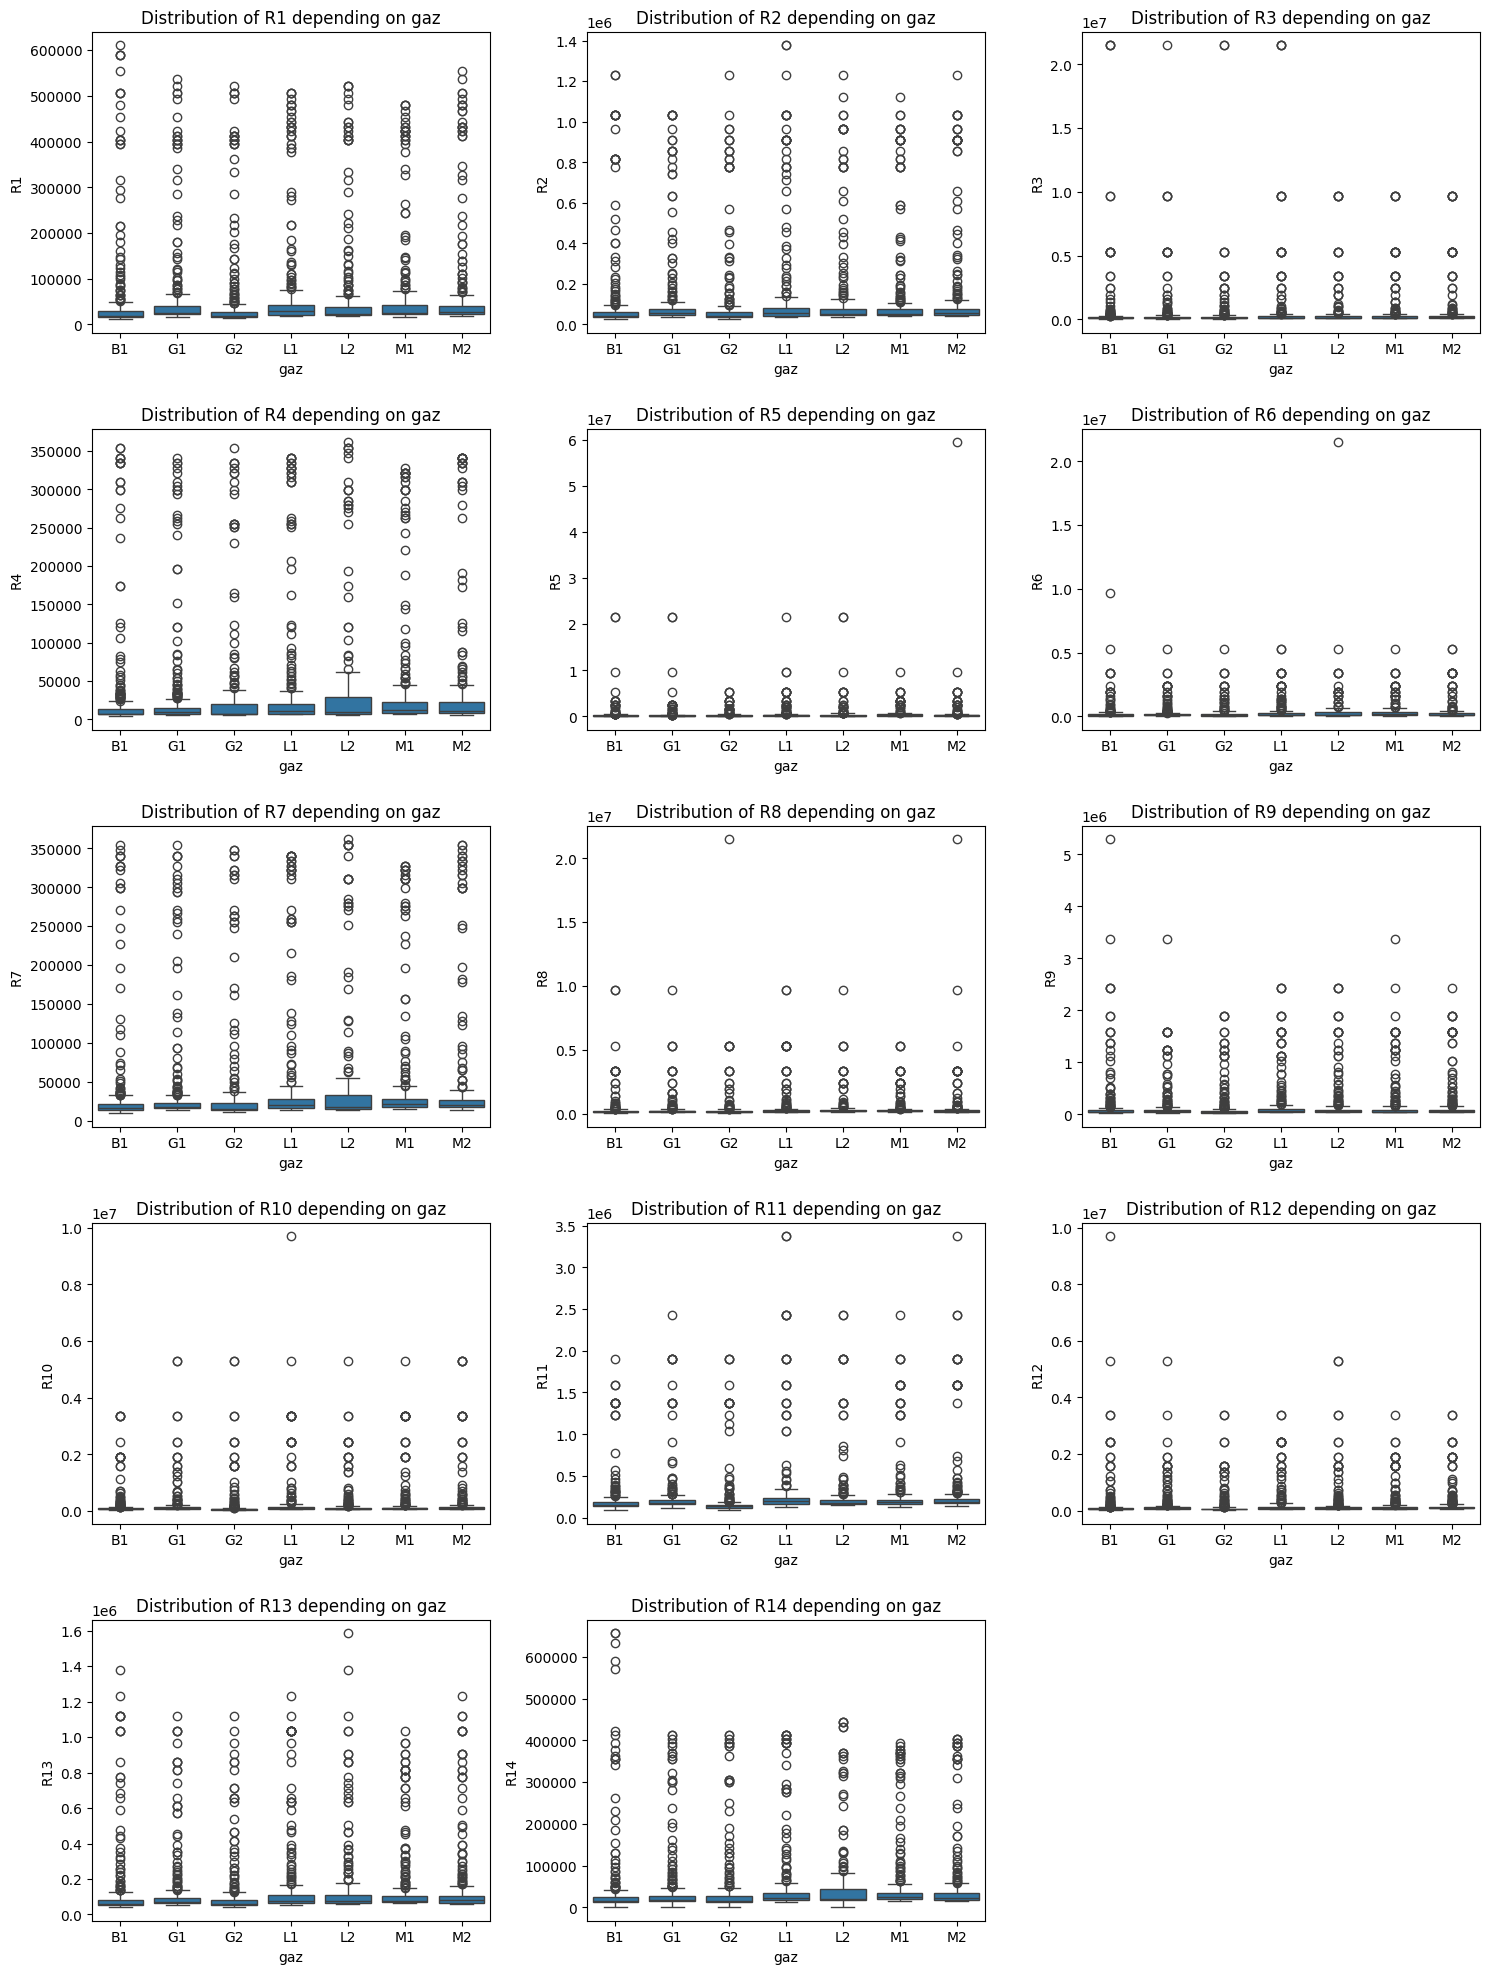

In [195]:
plot_distribution_by_target(df1, col_R, target)

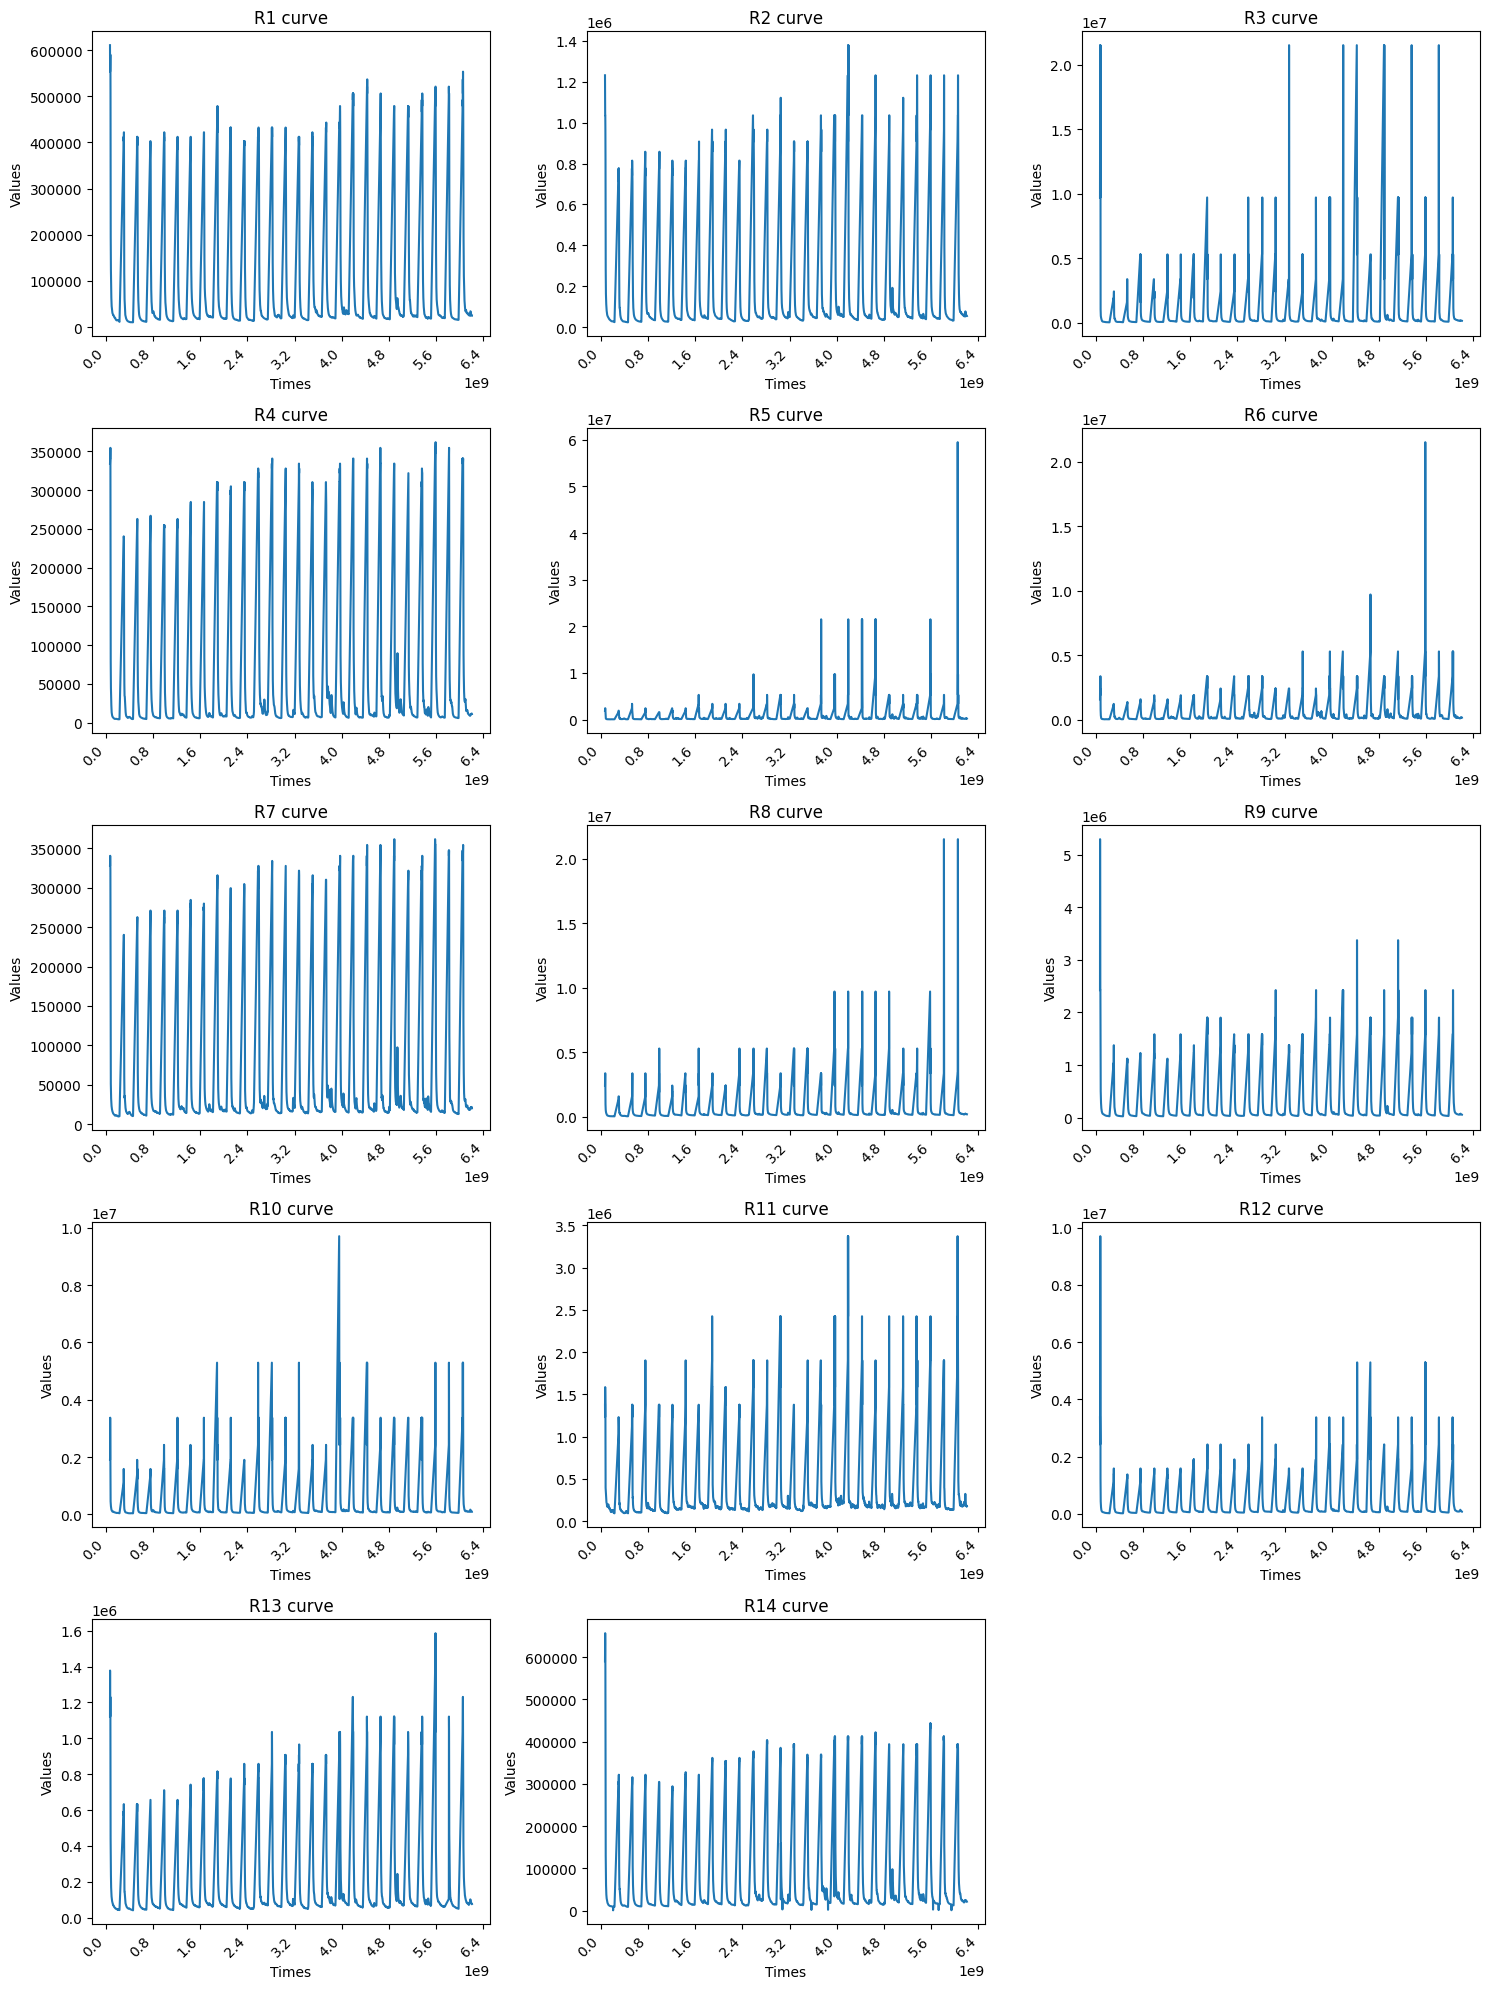

In [196]:
plot_duration(df1, col_R, 'Time')

# AAA

In [211]:
df2 = df1.copy()
print(df2.shape)

# Identifier les changements de gaz
df2['gaz_change'] = df2['gaz'] != df2['gaz'].shift(1)

# Créer un groupe à chaque changement de gaz
df2['group_id'] = df2['gaz_change'].cumsum()

# Calculer la durée totale de chaque groupe (pour connaître la fin de la période)
df2['group_duration'] = df2.groupby('group_id')['Time'].transform(lambda x: x.max() - x.min())

# Calculer le temps écoulé depuis le début du groupe
df2['time_elapsed'] = df2.groupby('group_id')['Time'].transform(lambda x: x - x.min())

# Filtrer :
# 1. Le temps écoulé doit être > 60 secondes (début)
# 2. Le temps restant (durée totale - temps écoulé) doit être > 30 secondes (fin)
# Note : time_elapsed + 30s < group_duration équivaut à exclure les 30 dernières secondes
df2 = df2[
    (df2['time_elapsed'] > pd.Timedelta(seconds=60)) & 
    (df2['group_duration'] - df2['time_elapsed'] > pd.Timedelta(seconds=5))
]

# Nettoyage des colonnes temporaires
df2 = df2.drop(columns=['gaz_change', 'group_id', 'group_duration', 'time_elapsed'])
print(df2.shape)

(2471, 17)
(1183, 17)


In [206]:
# Target balance
df2['gaz'].value_counts()

gaz
L1    236
B1    216
G1    216
G2    215
L2    214
M1    214
M2    212
Name: count, dtype: int64

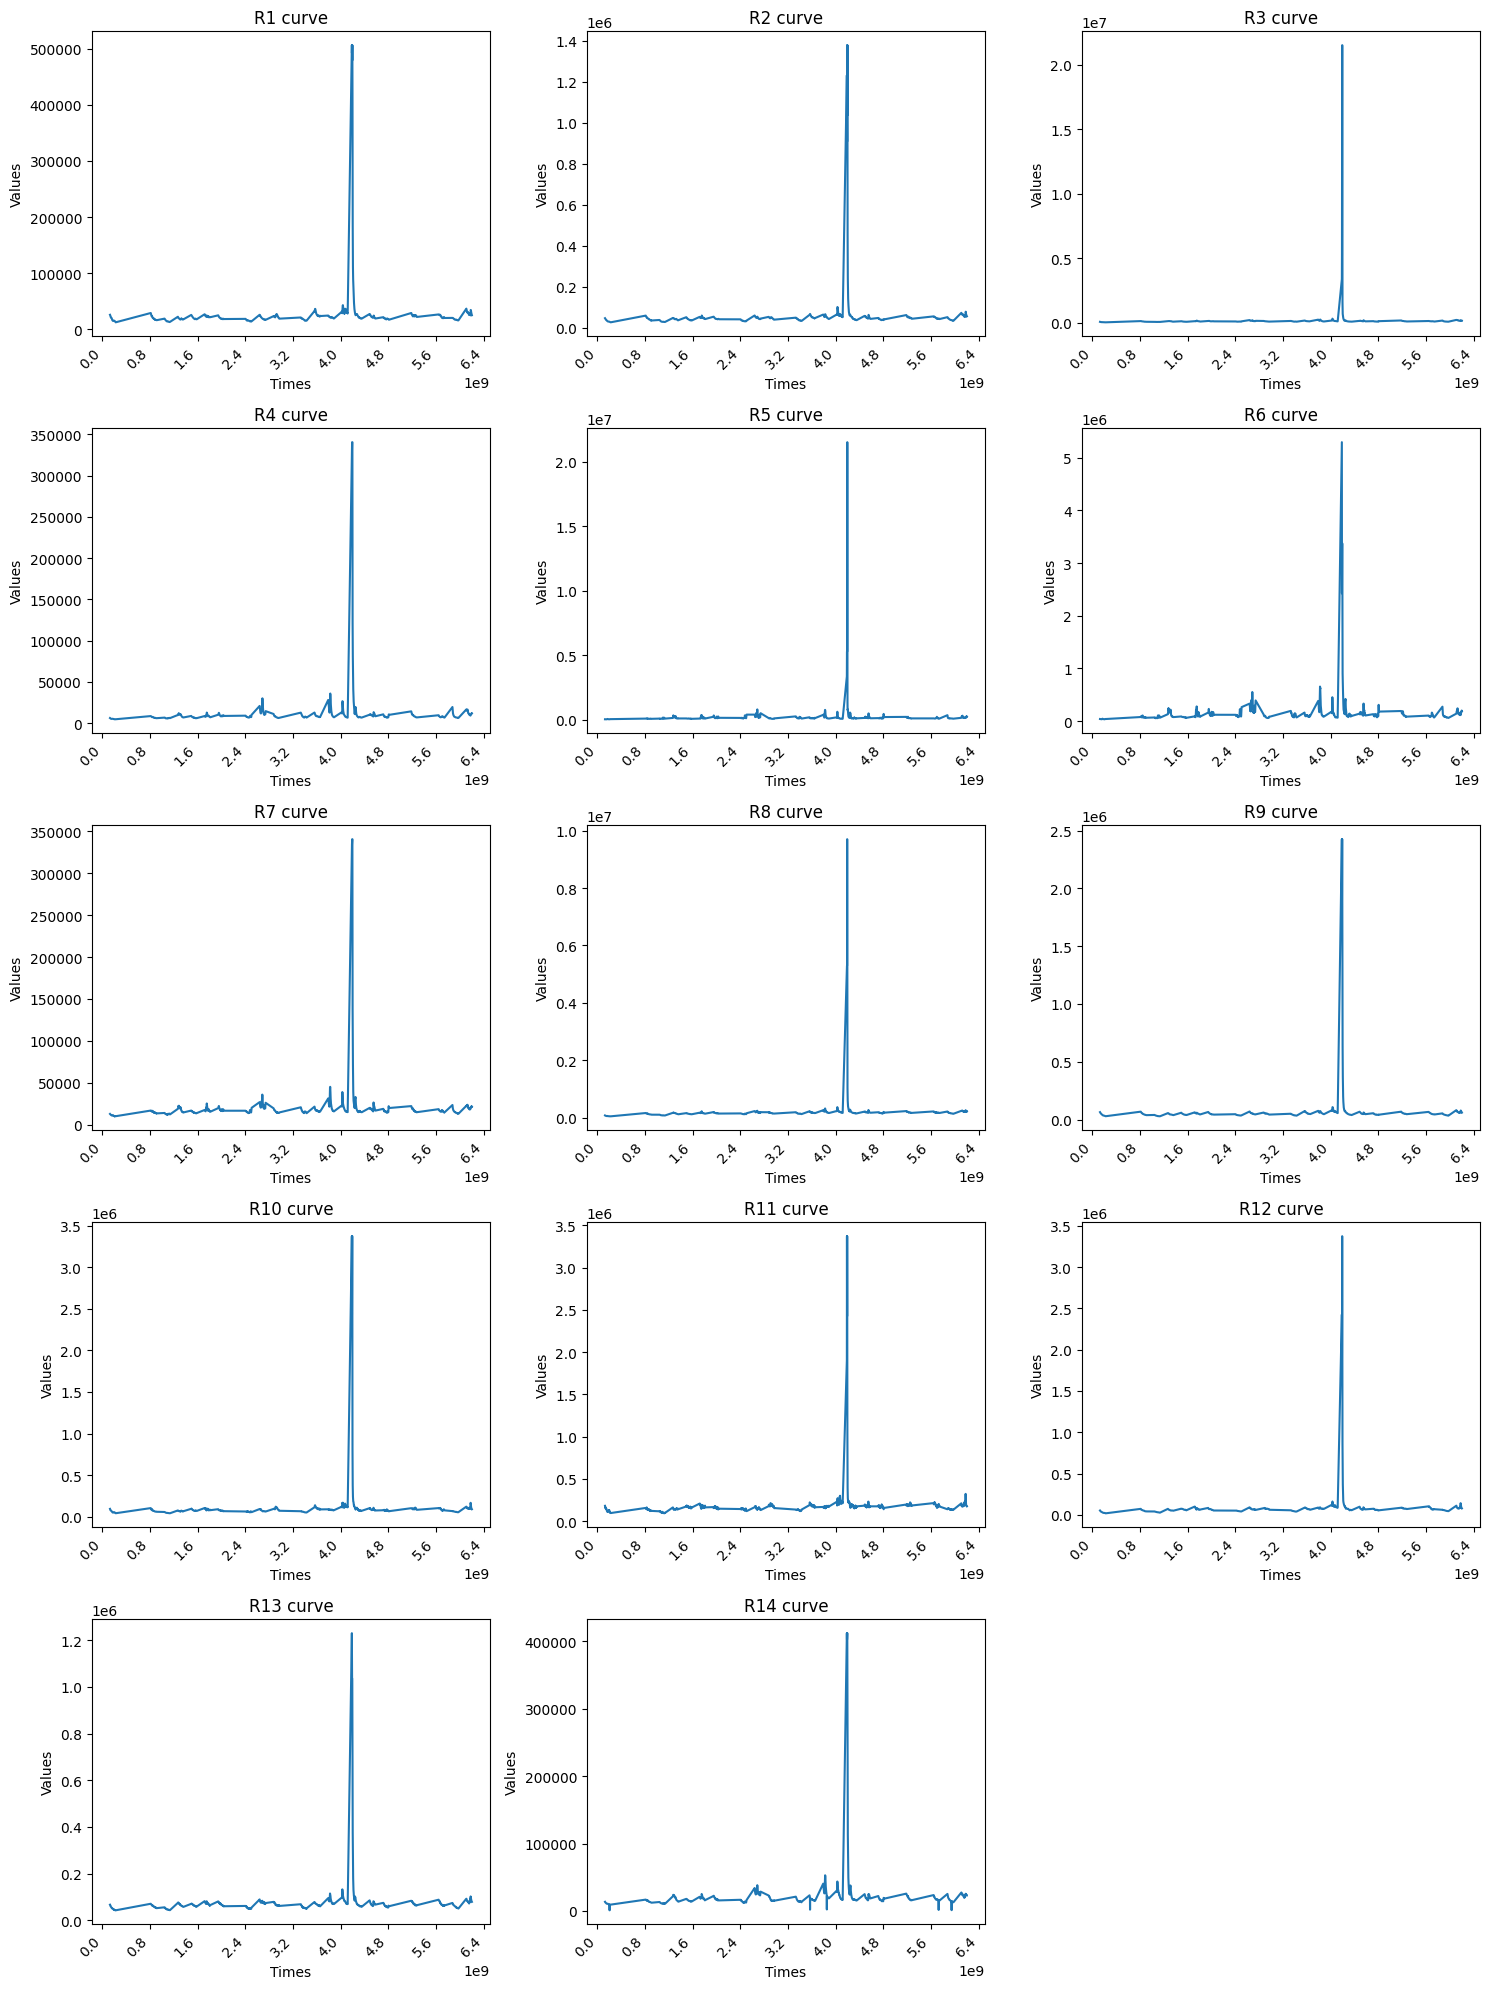

In [212]:
plot_duration(df2, col_R, 'Time')

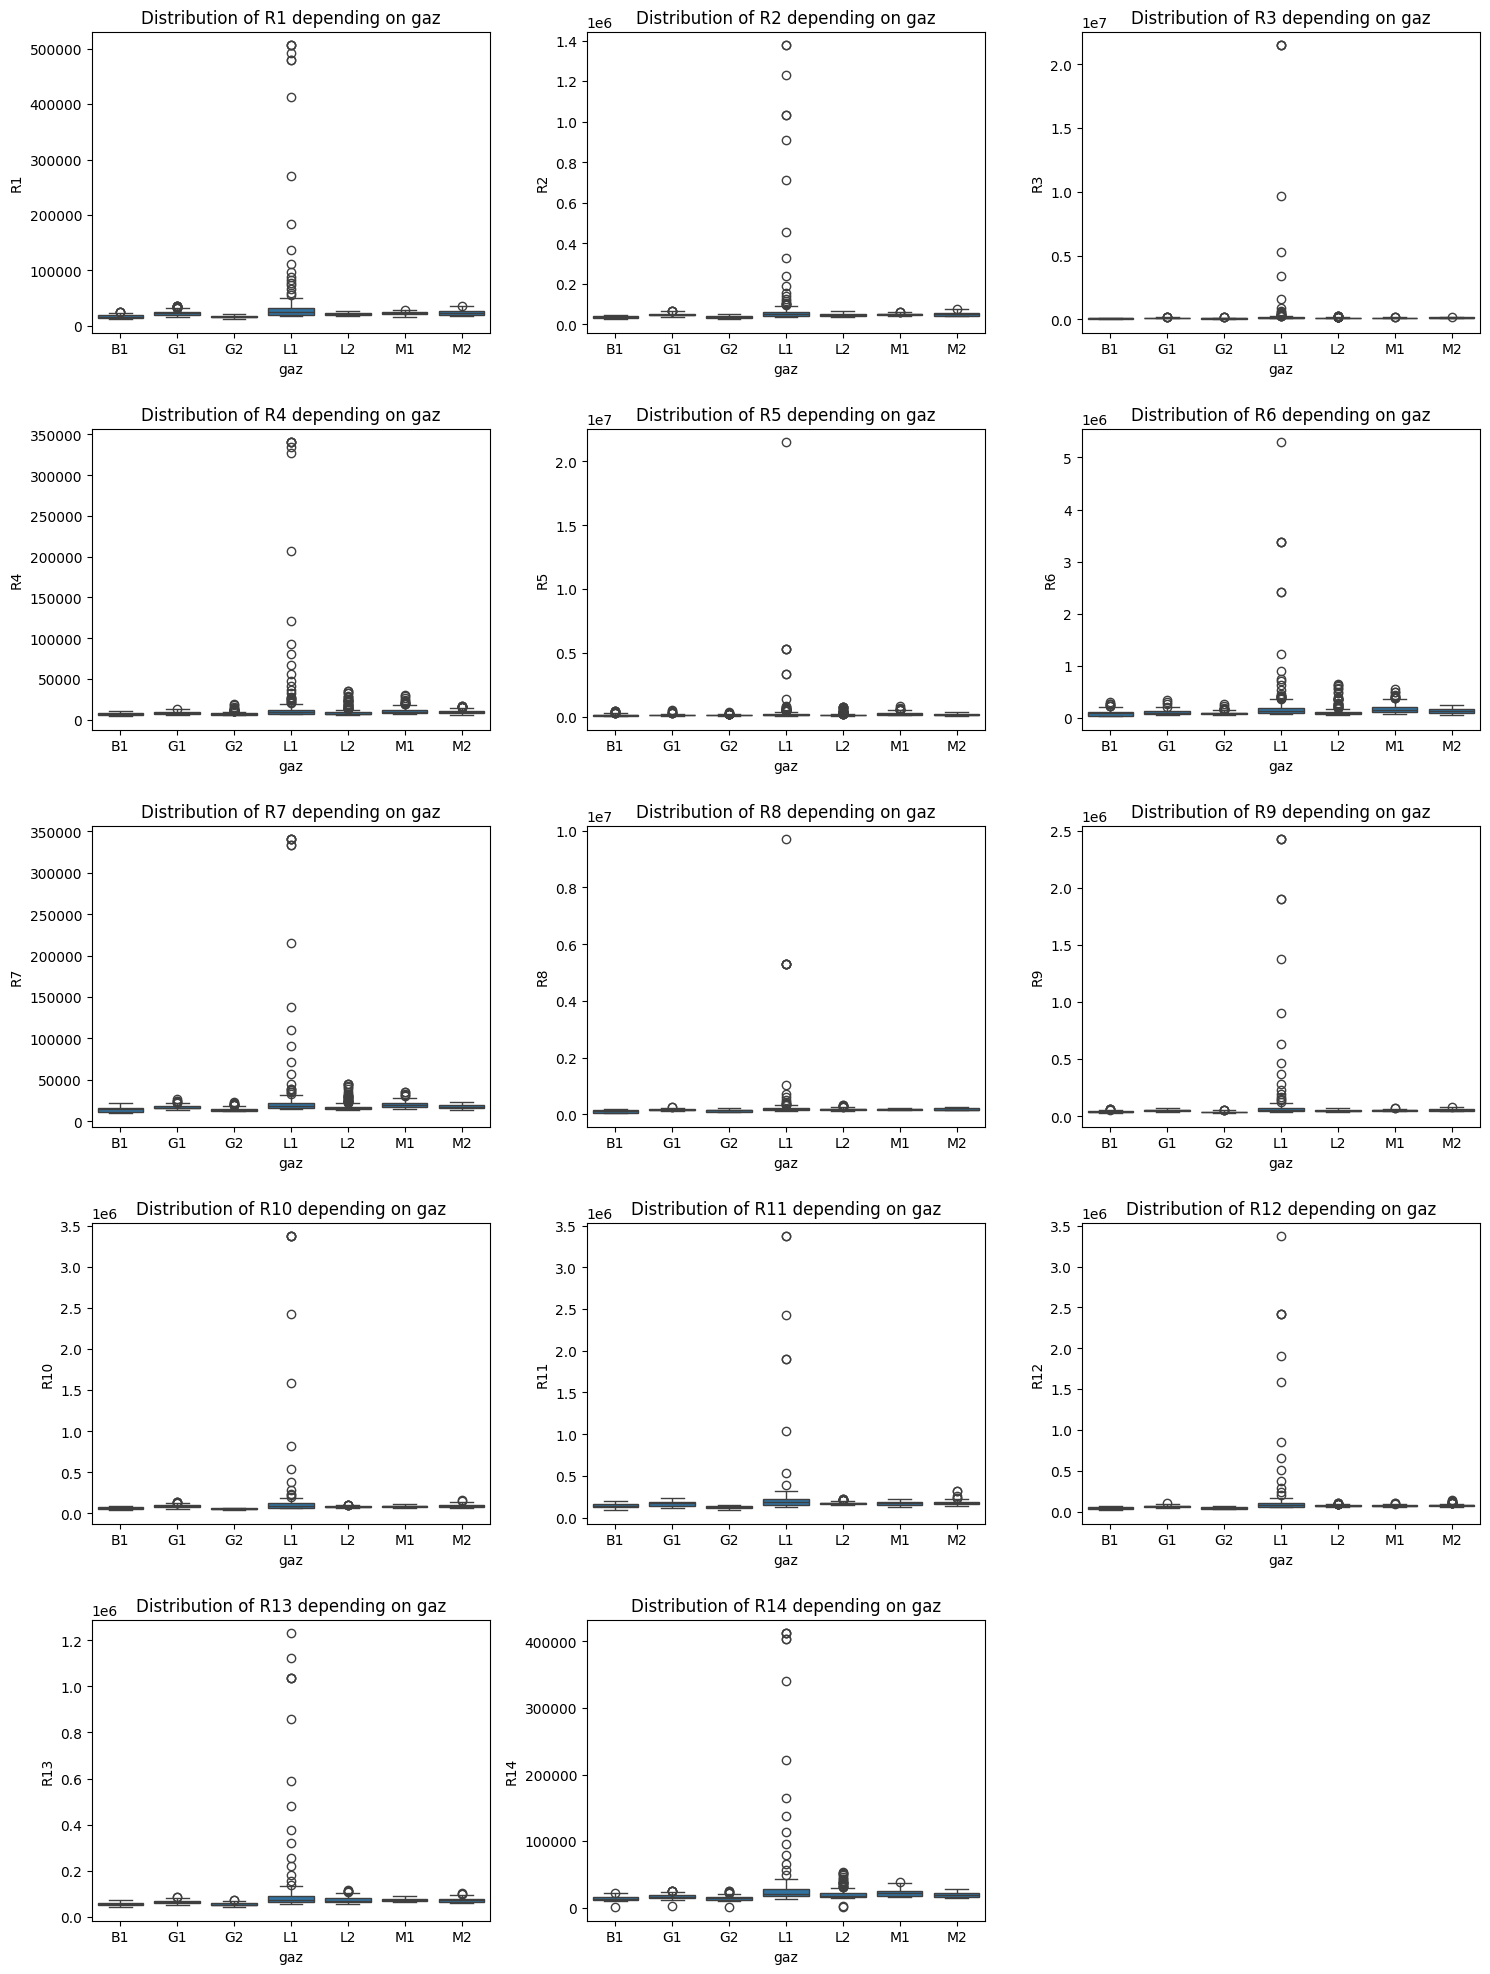

In [213]:
plot_distribution_by_target(df2, col_R, target)

# Clustering


In [201]:
def split_data(data):
    data = data.drop(columns=['Time'])

    X = data.drop(columns=['gaz'])
    y = data['gaz']

    return X, y

def drop_R(data):
    data = data.drop(columns=['R1','R2', 'R3','R9', 'R10', 'R12'])

    return data

def delete_A(data):
    data = data[data['gaz'] != 'A']

    return data

def delete_stabilisation(data):
    # Identifier les changements de gaz
    data['gaz_change'] = data['gaz'] != data['gaz'].shift(1)

    # Créer un groupe à chaque changement de gaz
    data['group_id'] = data['gaz_change'].cumsum()

    # Calculer la durée totale de chaque groupe (pour connaître la fin de la période)
    data['group_duration'] = data.groupby('group_id')['Time'].transform(lambda x: x.max() - x.min())

    # Calculer le temps écoulé depuis le début du groupe
    data['time_elapsed'] = data.groupby('group_id')['Time'].transform(lambda x: x - x.min())

    # Filtrer :
    # 1. Le temps écoulé doit être > 60 secondes (début)
    # 2. Le temps restant (durée totale - temps écoulé) doit être > 30 secondes (fin)
    # Note : time_elapsed + 30s < group_duration équivaut à exclure les 30 dernières secondes
    data = data[
        (data['time_elapsed'] > pd.Timedelta(seconds=60)) & 
        (data['group_duration'] - data['time_elapsed'] > pd.Timedelta(seconds=5))
    ]

    # Nettoyage des colonnes temporaires
    data = data.drop(columns=['gaz_change', 'group_id', 'group_duration', 'time_elapsed'])

    return data

In [202]:
from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [203]:
def PCA_visu(X, y):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    sklearn_pca = PCA(n_components=3)
    X_pca_sklearn = sklearn_pca.fit_transform(X, y)

    data_pca = pd.DataFrame(X_pca_sklearn, columns=['PC1', 'PC2', 'PC3'])
    data_pca['gaz'] = y



    fig = px.scatter_3d(
    data_pca,
    x='PC1', y='PC2', z='PC3',
    color='gaz',
    title='Visualisation 3D Interactive (PCA)',
    labels={'PC1': 'Composante 1', 'PC2': 'Composante 2', 'PC3': 'Composante 3'},
    opacity=0.7,
    height=400,  
    width=600
    )

    # Amélioration de l'affichage
    fig.update_traces(marker=dict(size=5))
    fig.show()

def LDA_visu(X, y):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    sklearn_lda = LDA(n_components=3)
    X_lda_sklearn = sklearn_lda.fit_transform(X, y)

    data_lda = pd.DataFrame(X_lda_sklearn, columns=['LD1', 'LD2', 'LD3'])
    data_lda['gaz'] = y



    fig = px.scatter_3d(
    data_lda,
    x='LD1', y='LD2', z='LD3',
    color='gaz',
    title='Visualisation 3D Interactive (LDA)',
    labels={'LD1': 'Composante 1', 'LD2': 'Composante 2', 'LD3': 'Composante 3'},
    opacity=0.7,
    height=400,  
    width=600
    )

    # Amélioration de l'affichage
    fig.update_traces(marker=dict(size=5))
    fig.show()

In [204]:
df = data_raw.copy()
df['Time'] = pd.to_timedelta(df['Time'])


df = delete_A(df)
# df = drop_R(df)
df = delete_stabilisation(df)

X, y = split_data(df)

PCA_visu(X, y)
LDA_visu(X, y)

# Split data

In [214]:
df2 = df2.drop(columns=['Time'])

In [215]:
X = df2.drop(columns=['gaz'])
y = df2['gaz']

In [216]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
label_encoder = enc.fit(y)
y = label_encoder.transform(y)

In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

In [218]:
print(f"Shape train data : {X_train.shape}")

val, count = np.unique(y_train, return_counts=True)
#
for v, c in zip(val, count):
    print(f"Value {v}: {c}")

Shape train data : (828, 15)
Value 0: 115
Value 1: 116
Value 2: 115
Value 3: 141
Value 4: 114
Value 5: 114
Value 6: 113


In [219]:
print(f"Shape test data : {X_test.shape}")

val, count = np.unique(y_test, return_counts=True)
#
for v, c in zip(val, count):
    print(f"Value {v}: {c}")

Shape test data : (355, 15)
Value 0: 50
Value 1: 49
Value 2: 49
Value 3: 61
Value 4: 49
Value 5: 49
Value 6: 48


# Model

In [220]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

from sklearn.metrics import roc_auc_score

In [221]:
models = {
    'Log_Reg': LogisticRegression(max_iter=10000, random_state=0),
    'Random_forest': RandomForestClassifier(random_state=0),
    'Gradient_Boosting': GradientBoostingClassifier(random_state=0),
    'XGBOOST': XGBClassifier(random_state=0),
    'SVC': SVC(random_state=0),
    'KNN': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
}

In [222]:
def score_model(y_test, y_pred):
    # Number of accurate classification
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy score : {accuracy}")
    # Calculate f1 score of every class and then average them
    macro_averaged_f1 = f1_score(y_test, y_pred, average = 'macro')
    print(f"F1 score (Macro-Averaged) : {macro_averaged_f1}")

In [223]:
for name, model in models.items():
    scaler_pipe = Pipeline(steps=[
        ('scaler', RobustScaler()),
        ('model', model),
        ])

    scaler_pipe.fit(X_train, y_train)
    y_pred = scaler_pipe.predict(X_test)

    print(f'{name}:')
    score_model(y_test, y_pred)
    print('============')

Log_Reg:
Accuracy score : 0.7098591549295775
F1 score (Macro-Averaged) : 0.7027587265131187
Random_forest:
Accuracy score : 0.9183098591549296
F1 score (Macro-Averaged) : 0.9165431183251054
Gradient_Boosting:
Accuracy score : 0.9154929577464789
F1 score (Macro-Averaged) : 0.9154623417117236
XGBOOST:
Accuracy score : 0.9323943661971831
F1 score (Macro-Averaged) : 0.932406936068664
SVC:
Accuracy score : 0.3154929577464789
F1 score (Macro-Averaged) : 0.2313801650482606
KNN:
Accuracy score : 0.8929577464788733
F1 score (Macro-Averaged) : 0.8929795046159669
GaussianNB:
Accuracy score : 0.38591549295774646
F1 score (Macro-Averaged) : 0.3801943119963336


In [224]:
from sklearn.model_selection import learning_curve

def model_learning_curve(X_train, y_train, pipe, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
    )

    return train_sizes, train_scores, val_scores


def learning_curve_plot(lc_data):
    n_models = len(lc_data)
    cols = 3
    rows = int(np.ceil(n_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for ax, data in zip(axes, lc_data):

        size = data['t_size']
        tscore = data['t_score']
        vscore = data['v_score']

        train_scores_mean = tscore.mean(axis=1)
        val_scores_mean = vscore.mean(axis=1)

        ax.plot(size, train_scores_mean, marker='o', label='Train')
        ax.plot(size, val_scores_mean, marker='o', label='Validation')

        ax.set_title(data['model'])
        ax.grid(True, linestyle='--', alpha=0.7)

        ax.legend(loc='best')

    plt.tight_layout()
    plt.show()

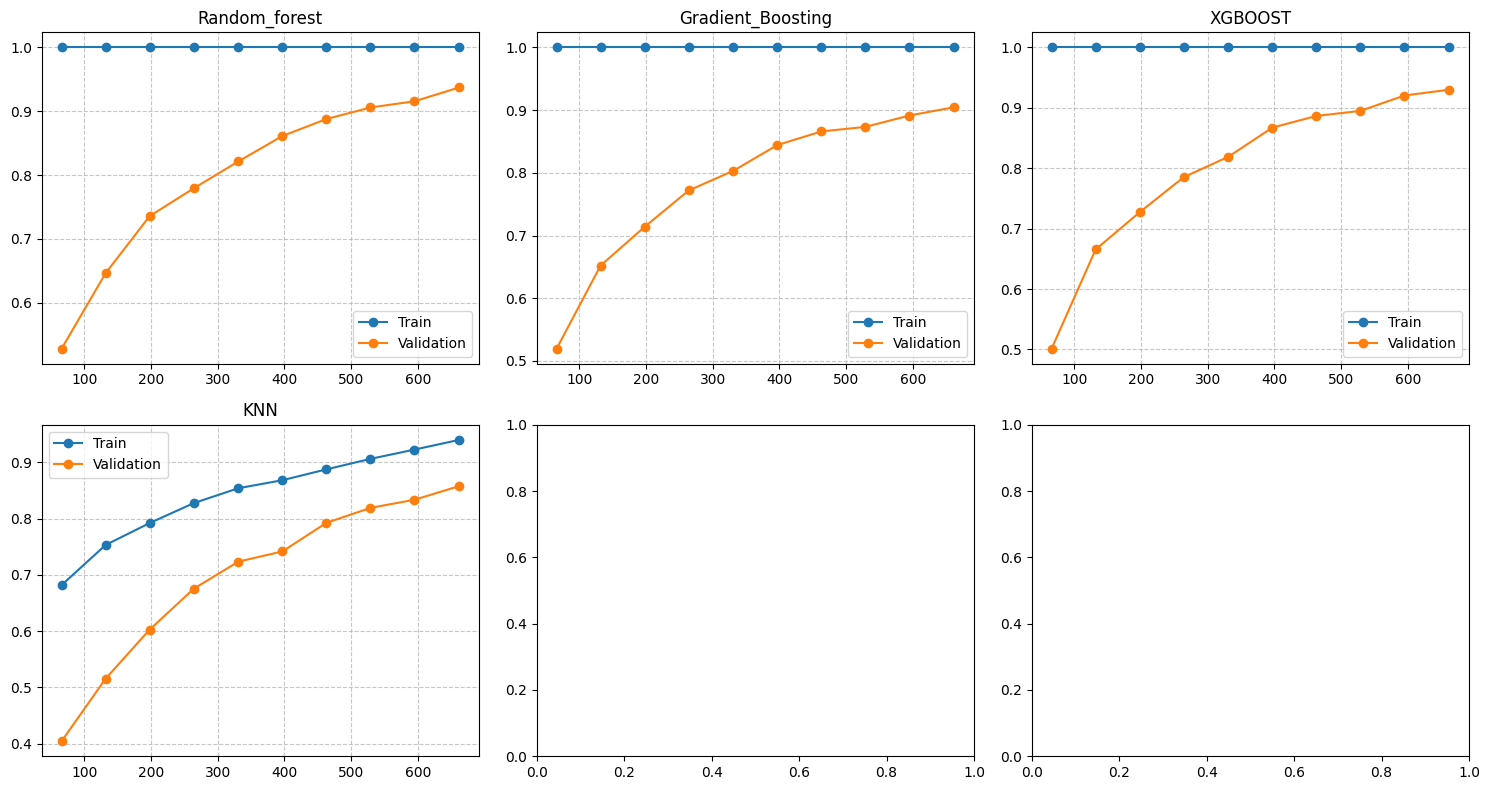

In [225]:
from sklearn.model_selection import KFold

models = {
    'Random_forest': RandomForestClassifier(random_state=0),
    'Gradient_Boosting': GradientBoostingClassifier(random_state=0),
    'XGBOOST': XGBClassifier(random_state=0),
    'KNN': KNeighborsClassifier(),
}

cv = KFold(n_splits=5, shuffle=True, random_state=0)

lc_data = []

for name, model in models.items():
    scaler_pipe = Pipeline(steps=[
        ('scaler', RobustScaler()),
        ('model', model),
        ])

    train_sizes, train_scores, val_scores = model_learning_curve(X_train, y_train, scaler_pipe, cv)

    lc_data.append({
        'model': name,
        't_size': train_sizes,
        't_score': train_scores,
        'v_score': val_scores
    })

learning_curve_plot(lc_data)

In [226]:
# ovo = OneVsOneClassifier(estimator=SVC())
# scaler_pipe = Pipeline(steps=[
#     ('scaler', RobustScaler()),
#     ('model', ovo),
#     ])

# ovr = OneVsRestClassifier(estimator=GradientBoostingClassifier())
# scaler_pipe = Pipeline(steps=[
#     ('scaler', RobustScaler()),
#     ('model', ovr),
#     ])

scaler_pipe = Pipeline(steps=[
    ('scaler', RobustScaler()),
    ('model', RandomForestClassifier()),
    ])

scaler_pipe.fit(X_train, y_train)

y_pred = scaler_pipe.predict(X_test)
y_proba = scaler_pipe.predict_proba(X_test)

score_model(y_test, y_pred)

Accuracy score : 0.9295774647887324
F1 score (Macro-Averaged) : 0.9289166446382942


In [227]:
cm = confusion_matrix(y_test, y_pred)
class_names = enc.classes_
classes = scaler_pipe.classes_

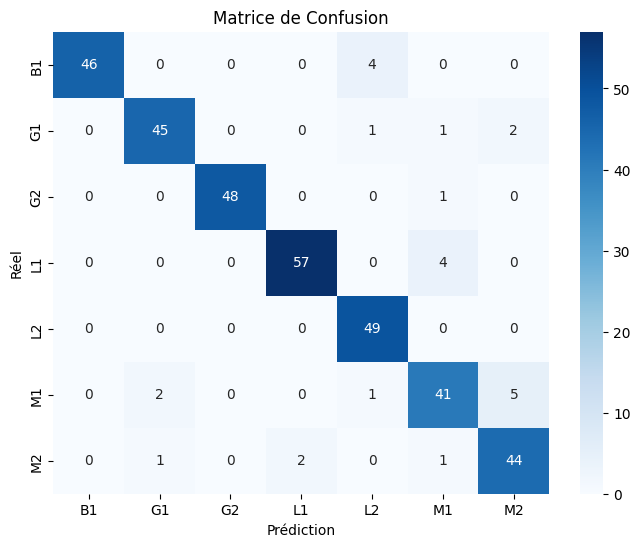

In [228]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

In [229]:
def calculate_tpr_fpr(y_real, y_pred):
    '''
    Calculates the True Positive Rate (tpr) and the True Negative Rate (fpr) based on real and predicted observations
    
    Args:
        y_real: The list or series with the real classes
        y_pred: The list or series with the predicted classes
        
    Returns:
        tpr: The True Positive Rate of the classifier
        fpr: The False Positive Rate of the classifier
    '''
    
    # Calculates the confusion matrix and recover each element
    cm = confusion_matrix(y_real, y_pred)
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    
    # Calculates tpr and fpr
    tpr =  TP/(TP + FN) # sensitivity - true positive rate
    fpr = 1 - TN/(TN+FP) # 1-specificity - false positive rate
    
    return tpr, fpr

def get_all_roc_coordinates(y_real, y_proba):
    '''
    Calculates all the ROC Curve coordinates (tpr and fpr) by considering each point as a threshold for the predicion of the class.
    
    Args:
        y_real: The list or series with the real classes.
        y_proba: The array with the probabilities for each class, obtained by using the `.predict_proba()` method.
        
    Returns:
        tpr_list: The list of TPRs representing each threshold.
        fpr_list: The list of FPRs representing each threshold.
    '''
    tpr_list = [0]
    fpr_list = [0]
    for i in range(len(y_proba)):
        threshold = y_proba[i]
        y_pred = y_proba >= threshold
        tpr, fpr = calculate_tpr_fpr(y_real, y_pred)
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    return tpr_list, fpr_list

def plot_roc_curve(tpr, fpr, scatter = True, ax = None):
    '''
    Plots the ROC Curve by using the list of coordinates (tpr and fpr).
    
    Args:
        tpr: The list of TPRs representing each coordinate.
        fpr: The list of FPRs representing each coordinate.
        scatter: When True, the points used on the calculation will be plotted with the line (default = True).
    '''
    if ax == None:
        plt.figure(figsize = (5, 5))
        ax = plt.axes()
    
    if scatter:
        sns.scatterplot(x = fpr, y = tpr, ax = ax)
    sns.lineplot(x = fpr, y = tpr, ax = ax)
    sns.lineplot(x = [0, 1], y = [0, 1], color = 'green', ax = ax)
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

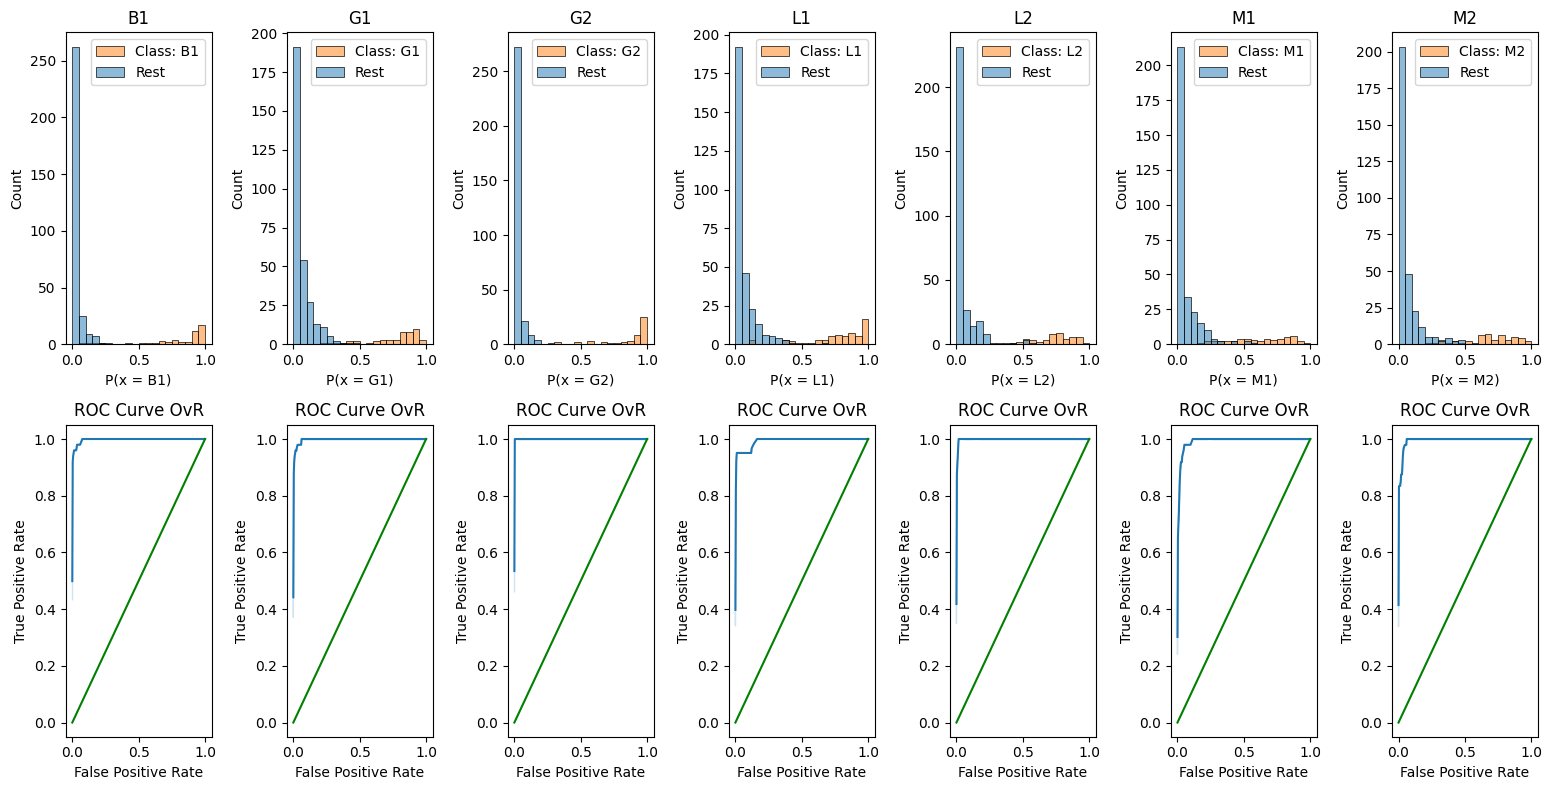

In [230]:
plt.figure(figsize = (20, 8))
bins = [i/20 for i in range(20)] + [1]
roc_auc_ovr = {}

for i in range(len(classes)):
    # Gets the class
    c_name = class_names[i]
    c_val = classes[i] 
    
    # Prepares an auxiliar dataframe to help with the plots
    df_aux = X_test.copy()
    df_aux['class'] = [1 if y == c_val else 0 for y in y_test]
    df_aux['prob'] = y_proba[:, i]
    df_aux = df_aux.reset_index(drop=True)
    
    # Plots the probability distribution for the class and the rest
    ax = plt.subplot(2, 9, i+1)
    sns.histplot(x = "prob", data = df_aux, hue = 'class', color = 'b', ax = ax, bins = bins)
    ax.set_title(c_name)
    ax.legend([f"Class: {c_name}", "Rest"])
    ax.set_xlabel(f"P(x = {c_name})")
    
    # Calculates the ROC Coordinates and plots the ROC Curves
    ax_bottom = plt.subplot(2, 9, i+10)
    tpr, fpr = get_all_roc_coordinates(df_aux['class'], df_aux['prob'])
    plot_roc_curve(tpr, fpr, scatter = False, ax = ax_bottom)
    ax_bottom.set_title("ROC Curve OvR")
    
    # Calculates the ROC AUC OvR
    roc_auc_ovr[c_name] = roc_auc_score(df_aux['class'], df_aux['prob'])
    
plt.tight_layout()

In [231]:
# Displays the ROC AUC for each class
avg_roc_auc = 0
i = 0
for k in roc_auc_ovr:
    avg_roc_auc += roc_auc_ovr[k]
    i += 1
    print(f"{k} ROC AUC OvR: {roc_auc_ovr[k]:.4f}")
print(f"average ROC AUC OvR: {avg_roc_auc/i:.4f}")

B1 ROC AUC OvR: 0.9977
G1 ROC AUC OvR: 0.9976
G2 ROC AUC OvR: 1.0000
L1 ROC AUC OvR: 0.9926
L2 ROC AUC OvR: 0.9988
M1 ROC AUC OvR: 0.9917
M2 ROC AUC OvR: 0.9947
average ROC AUC OvR: 0.9961
